In [1]:
# importing needed packages
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
# read in the cleaned CSV with data from central valley stations
path = 'E:/Central Valley Fog/CV_station_rows_nonna.csv'
if os.path.exists(path):
    CV_rows = pd.read_csv(path, low_memory = False)
else:
    path = '/Volumes/disk1/Central Valley Fog/CV_station_rows_nonna.csv'
    CV_rows = pd.read_csv(path, low_memory = False)

print(CV_rows)

# # read in the cleaned CSV with data from central valley stations
# path = 'E:/Central Valley Fog/CV_all_rows_wind_codes_temp.csv'
# if os.path.exists(path):
#     CV_rows = pd.read_csv(path, low_memory = False)
# else:
#     path = '/Volumes/disk1/Central Valley Fog/CV_all_rows_wind_codes_temp.csv'
#     CV_rows = pd.read_csv(path, low_memory = False)

# print(CV_rows)

          STATION_ID  LATITUDE  LONGITUDE                 DATE REPORT_TYPE  \
0        USW00093193   36.7800  -119.7194  1941-12-04 00:00:00         SAO   
1        USW00093193   36.7800  -119.7194  1941-12-04 01:00:00         SAO   
2        USW00093193   36.7800  -119.7194  1941-12-04 02:00:00         SAO   
3        USW00093193   36.7800  -119.7194  1941-12-04 03:00:00         SAO   
4        USW00093193   36.7800  -119.7194  1941-12-04 04:00:00         SAO   
...              ...       ...        ...                  ...         ...   
8221089  USW00024257   40.5175  -122.2986  2026-06-20 04:53:00       FM-15   
8221090  USW00024257   40.5175  -122.2986  2026-06-20 05:53:00       FM-15   
8221091  USW00024257   40.5175  -122.2986  2026-06-20 06:53:00       FM-15   
8221092  USW00024257   40.5175  -122.2986  2026-06-20 07:53:00       FM-15   
8221093  USW00024257   40.5175  -122.2986  2026-06-20 08:53:00       FM-15   

         HourlyDewPointTemperature  HourlyDryBulbTemperature  \

In [3]:
#Remove duplicate hours for each station
CV_rows = CV_rows.drop_duplicates(subset=['STATION', 'year', 'month', 'day', 'hour'])

print(CV_rows.shape)

(7251147, 18)


In [4]:
# Exclude days from April through October (months 4-10) in CV_rows
CV_rows = CV_rows[~CV_rows['month'].isin([4, 5, 6, 7, 8, 9, 10])]

print("CV_rows after removing April-October:", CV_rows.shape)

CV_rows after removing April-October: (3035802, 18)


In [5]:
# Exclude the year 2026
CV_rows = CV_rows[CV_rows['year'] != 2026]

print("CV_data after removing year 2026:", CV_rows.shape)

CV_data after removing year 2026: (3007526, 18)


In [6]:
# Find the earliest year with recorded data for each station
earliest_year_by_station = CV_rows.groupby("STATION")["year"].min().reset_index()
earliest_year_by_station.columns = ["STATION", "earliest_year"]
earliest_year_by_station = earliest_year_by_station.sort_values("earliest_year")

print("Earliest year with recorded data for each station:")
print(earliest_year_by_station)

Earliest year with recorded data for each station:
                       STATION  earliest_year
0               BAKERSFIELD AP           1928
9        SACRAMENTO MATHER AFB           1930
8           SACRAMENTO AP ASOS           1931
6            RED BLUFF MUNI AP           1939
10    SACRAMENTO MCCLELLAN AFB           1939
12                 STOCKTON AP           1941
3         FRESNO YOSEMITE INTL           1941
2                   CASTLE AFB           1942
13            TRAVIS FIELD AFB           1943
7                   REDDING AP           1944
1                    BEALE AFB           1959
4           LEMOORE REEVES NAS           1961
11  SACRAMENTO METROPOLITAN AP           1972
5       LIVERMORE MUNICIPAL AP           1999


In [7]:
# Remove the earliest year for each station
CV_rows = CV_rows.merge(
    earliest_year_by_station,
    left_on="STATION",
    right_on="STATION",
    how="left"
)

CV_rows = CV_rows[CV_rows["year"] != CV_rows["earliest_year"]].drop(columns="earliest_year")

print("CV_rows after removing earliest year for each station:", CV_rows.shape)

CV_rows after removing earliest year for each station: (2988621, 18)


In [8]:
CV_rows['HourlyDewpointDepression'] = (
    CV_rows['HourlyDryBulbTemperature'] - CV_rows['HourlyDewPointTemperature']
)

CV_rows[['HourlyDryBulbTemperature', 'HourlyDewPointTemperature', 'HourlyDewpointDepression']].head()

,HourlyDryBulbTemperature,HourlyDewPointTemperature,HourlyDewpointDepression
671,3.0,3.0,0.0
672,3.0,3.0,0.0
673,3.5,2.4,1.1
674,3.5,3.5,0.0
675,3.5,3.5,0.0


In [9]:
# Ensure wind direction is numeric; "000" is treated as calm (0, 0)
wd1 = pd.to_numeric(CV_rows["HourlyWindDirection"], errors="coerce")

# Unit-vector style components from wind direction
# 360 = north, 180 = south, 270 = west, 90 = east
# Determine the north-south component of the wind direction
CV_rows["wind_ns_component"] = np.where(
    wd1.eq(0) | wd1.isna(),
    0.0,
    np.cos(np.deg2rad(wd1))
)

# Determine west-east component of the wind direction
CV_rows["wind_we_component"] = np.where(
    wd1.eq(0) | wd1.isna(),
    0.0,
    np.sin(np.deg2rad(wd1))
)

CV_rows[["HourlyWindDirection", "wind_ns_component", "wind_we_component"]].head()

,HourlyWindDirection,wind_ns_component,wind_we_component
671,45.0,0.707107,0.707107
672,45.0,0.707107,0.707107
673,0.0,0.000000,0.000000
674,315.0,0.707107,-0.707107
675,315.0,0.707107,-0.707107


In [10]:
# Classify each observation as up-valley or down-valley relative to valley angle = 330°
valley_angle = 330.0  # interpreted as the up-valley flow direction (toward 330°)

wd = pd.to_numeric(CV_rows["HourlyWindDirection"], errors="coerce")  # meteorological "from" direction
ws = pd.to_numeric(CV_rows["HourlyWindSpeed"], errors="coerce")

# Convert to "to" direction (direction wind is blowing toward)
wd_to = (wd + 180.0) % 360.0

# Signed alignment with valley axis (+ up-valley, - down-valley)
# cos(delta) > 0 means aligned with up-valley axis, < 0 means opposite (down-valley)
delta = np.deg2rad(wd_to - valley_angle)
valley_alignment = np.cos(delta)

# Optional speed-weighted along-valley component
CV_rows["valley_along_component"] = valley_alignment * ws

calm_mask = wd.eq(0) | ws.eq(0)  # "000" direction and/or zero speed => calm
missing_mask = wd.isna() | ws.isna()

# Classify each observation as "up_valley", "down_valley", "cross_valley", "calm", or "missing"
CV_rows["valley_wind_type"] = np.select(
    [
        missing_mask,
        calm_mask,
        valley_alignment > 0,
        valley_alignment < 0,
    ],
    [
        "missing",
        "calm",
        "up_valley",
        "down_valley",
    ],
    default="cross_valley",
)

# Quick station-level check of the counts of each valley wind type
station_valley_counts = (
    CV_rows.groupby(["STATION", "valley_wind_type"])
    .size()
    .unstack(fill_value=0)
)

station_valley_counts.head()

valley_wind_type,calm,down_valley,up_valley
STATION,,,
BAKERSFIELD AP,67478,134289,113430
BEALE AFB,42340,56443,82545
CASTLE AFB,67529,59766,57773
FRESNO YOSEMITE INTL,58319,95327,116329
LEMOORE REEVES NAS,38796,85717,62282


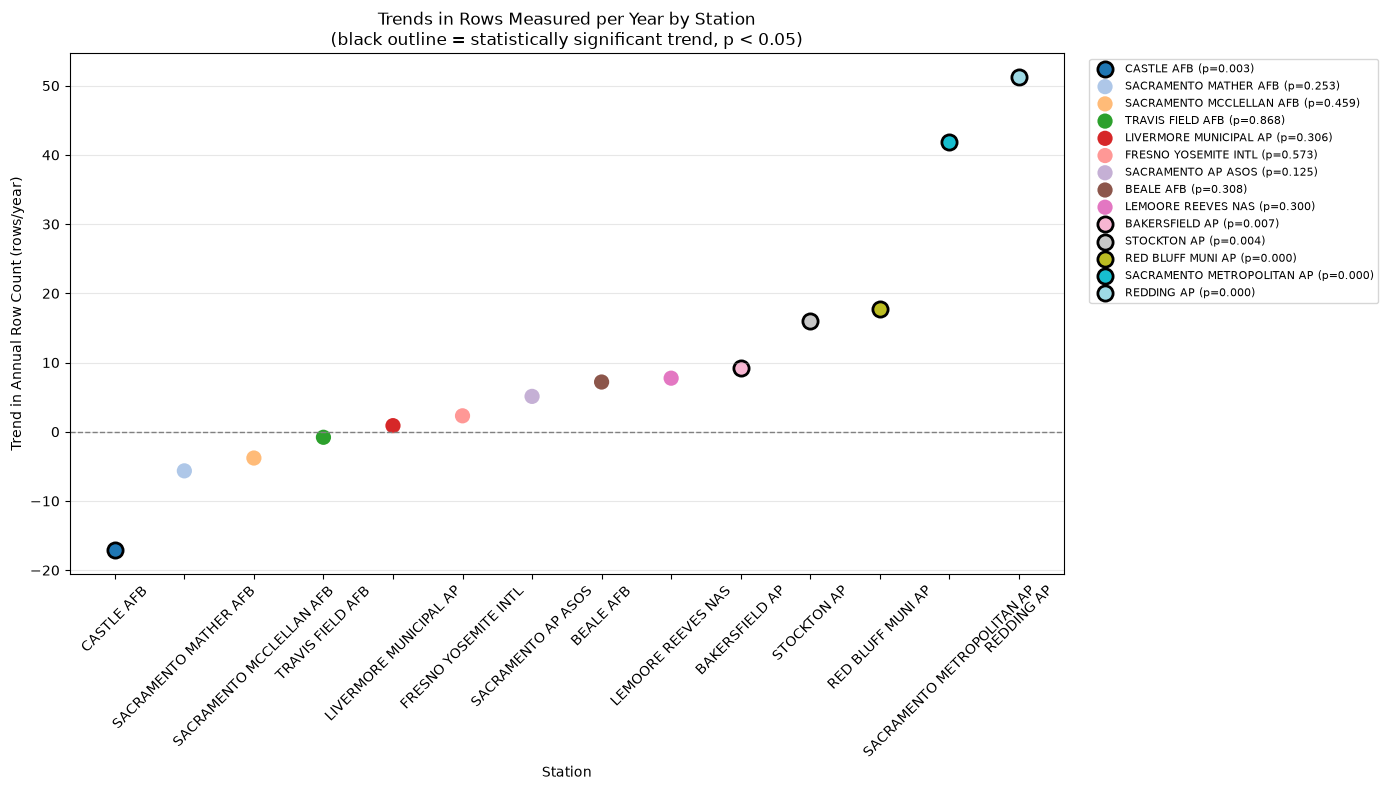

,STATION,slope_rows_per_year,p_value,n_years,significant
2,CASTLE AFB,-17.149729,3.496220e-03,65,True
9,SACRAMENTO MATHER AFB,-5.646104,2.530175e-01,76,False
10,SACRAMENTO MCCLELLAN AFB,-3.793639,4.593064e-01,71,False
13,TRAVIS FIELD AFB,-0.795773,8.679773e-01,76,False
5,LIVERMORE MUNICIPAL AP,0.884444,3.062234e-01,26,False
3,FRESNO YOSEMITE INTL,2.304894,5.726633e-01,81,False
8,SACRAMENTO AP ASOS,5.113709,1.251700e-01,94,False
1,BEALE AFB,7.188782,3.084873e-01,60,False
4,LEMOORE REEVES NAS,7.743613,3.004574e-01,64,False
0,BAKERSFIELD AP,9.183542,7.423653e-03,97,True


In [11]:
# Yearly row counts and station-level trends

yearly_row_counts = (
    CV_rows.groupby(["STATION", "year"])
    .size()
    .reset_index(name="row_count")
)

trend_records = []

for station, station_data in yearly_row_counts.groupby("STATION"):
    station_data = station_data.sort_values("year")

    if len(station_data) < 3:
        continue

    x = station_data["year"].to_numpy()
    y = station_data["row_count"].to_numpy()

    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    trend_records.append({
        "STATION": station,
        "slope_rows_per_year": slope,
        "p_value": p_value,
        "n_years": len(station_data),
        "significant": p_value < 0.05,
    })

trend_summary_rows = pd.DataFrame(trend_records).sort_values("slope_rows_per_year")

# Plot one trend datapoint per station
fig, ax = plt.subplots(figsize=(14, 8))

colors = plt.cm.tab20(np.linspace(0, 1, len(trend_summary_rows)))

for color, (_, row) in zip(colors, trend_summary_rows.iterrows()):
    ax.scatter(
        row["STATION"],
        row["slope_rows_per_year"],
        s=120,
        color=color,
        edgecolors="black" if row["significant"] else "none",
        linewidths=2 if row["significant"] else 0,
        label=(
            f'{row["STATION"]} '
            f'(p={row["p_value"]:.3f})'
        ),
    )

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Station")
ax.set_ylabel("Trend in Annual Row Count (rows/year)")
ax.set_title(
    "Trends in Rows Measured per Year by Station\n"
    "(black outline = statistically significant trend, p < 0.05)"
)
ax.tick_params(axis="x", rotation=45)
ax.grid(True, axis="y", alpha=0.3)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)

plt.tight_layout()
plt.show()

display(trend_summary_rows)

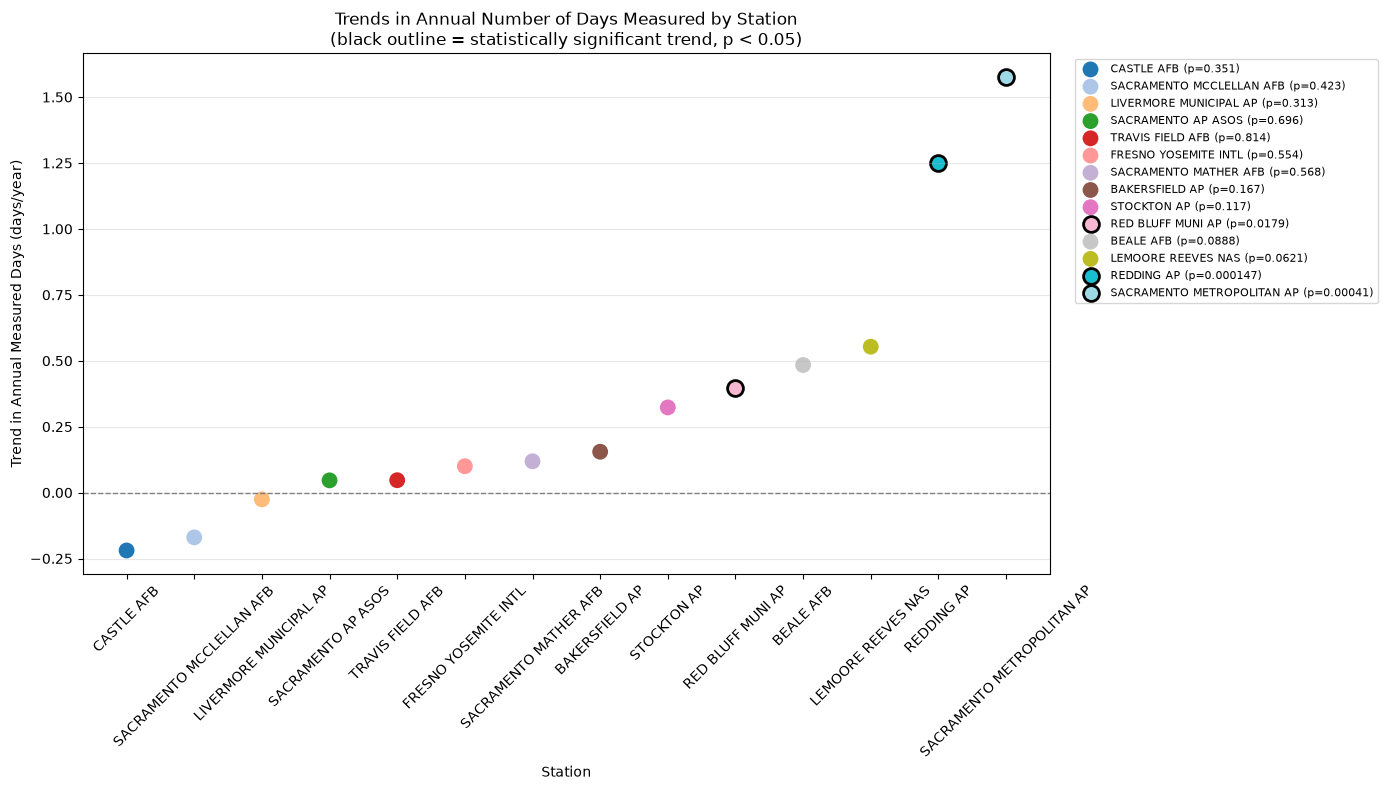

,STATION,slope_days_per_year,p_value,n_years,significant
2,CASTLE AFB,-0.219534,0.351422,65,False
10,SACRAMENTO MCCLELLAN AFB,-0.169793,0.422668,71,False
5,LIVERMORE MUNICIPAL AP,-0.025641,0.312626,26,False
8,SACRAMENTO AP ASOS,0.046418,0.696234,94,False
13,TRAVIS FIELD AFB,0.046901,0.814488,76,False
3,FRESNO YOSEMITE INTL,0.099942,0.554211,81,False
9,SACRAMENTO MATHER AFB,0.118704,0.568327,76,False
0,BAKERSFIELD AP,0.154955,0.167264,97,False
12,STOCKTON AP,0.322990,0.116563,74,False
6,RED BLUFF MUNI AP,0.396838,0.017898,83,True


In [12]:
# Annual number of unique measured days and trends by station

yearly_day_counts = (
    CV_rows[["STATION", "year", "month", "day"]]
    .drop_duplicates()
    .groupby(["STATION", "year"])
    .size()
    .reset_index(name="days_measured")
)

day_trend_records = []

for station, station_data in yearly_day_counts.groupby("STATION"):
    station_data = station_data.sort_values("year")

    if len(station_data) < 3:
        continue

    x_days = station_data["year"].to_numpy()
    y_days = station_data["days_measured"].to_numpy()

    slope, intercept, r_value, p_value, std_err = stats.linregress(
        x_days, y_days
    )

    day_trend_records.append({
        "STATION": station,
        "slope_days_per_year": slope,
        "p_value": p_value,
        "n_years": len(station_data),
        "significant": p_value < 0.05,
    })

day_trend_summary = (
    pd.DataFrame(day_trend_records)
    .sort_values("slope_days_per_year")
)

# Plot one trend point per station
fig, ax = plt.subplots(figsize=(14, 8))

station_colors_days = plt.cm.tab20(
    np.linspace(0, 1, len(day_trend_summary))
)

for color, (_, row) in zip(
    station_colors_days, day_trend_summary.iterrows()
):
    ax.scatter(
        row["STATION"],
        row["slope_days_per_year"],
        s=130,
        color=color,
        edgecolors="black" if row["significant"] else "none",
        linewidths=2 if row["significant"] else 0,
        label=f'{row["STATION"]} (p={row["p_value"]:.3g})',
    )

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Station")
ax.set_ylabel("Trend in Annual Measured Days (days/year)")
ax.set_title(
    "Trends in Annual Number of Days Measured by Station\n"
    "(black outline = statistically significant trend, p < 0.05)"
)
ax.tick_params(axis="x", rotation=45)
ax.grid(True, axis="y", alpha=0.3)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)

plt.tight_layout()
plt.show()

display(day_trend_summary)

In [13]:
# Print all column names from CV_rows

CV_rows.head()

,STATION_ID,LATITUDE,LONGITUDE,DATE,REPORT_TYPE,HourlyDewPointTemperature,HourlyDryBulbTemperature,HourlyPrecipitation,HourlyVisibility,HourlyWindDirection,...,month,day,hour,minute,STATION,HourlyDewpointDepression,wind_ns_component,wind_we_component,valley_along_component,valley_wind_type
671,USW00093193,36.78,-119.7194,1942-01-01 00:00:00,SAO,3.0,3.0,0.0,16.0,45.0,...,1,1,0,0,FRESNO YOSEMITE INTL,0.0,0.707107,0.707107,-0.258819,down_valley
672,USW00093193,36.78,-119.7194,1942-01-01 01:00:00,SAO,3.0,3.0,0.0,16.0,45.0,...,1,1,1,0,FRESNO YOSEMITE INTL,0.0,0.707107,0.707107,-0.129410,down_valley
673,USW00093193,36.78,-119.7194,1942-01-01 02:00:00,SAO,2.4,3.5,0.0,16.0,0.0,...,1,1,2,0,FRESNO YOSEMITE INTL,1.1,0.000000,0.000000,-0.000000,calm
674,USW00093193,36.78,-119.7194,1942-01-01 03:00:00,SAO,3.5,3.5,0.0,16.0,315.0,...,1,1,3,0,FRESNO YOSEMITE INTL,0.0,0.707107,-0.707107,-2.028444,down_valley
675,USW00093193,36.78,-119.7194,1942-01-01 04:00:00,SAO,3.5,3.5,0.0,16.0,315.0,...,1,1,4,0,FRESNO YOSEMITE INTL,0.0,0.707107,-0.707107,-1.448889,down_valley


In [14]:
# filtering based on precipitation
# filtering visibility threshold to identify outliers
CV_rows_dd_wind_filtered = CV_rows[
    (CV_rows["HourlyDewpointDepression"] < 2.0)
    & (CV_rows["HourlyWindSpeed"] < 5.0)
]

print("CV_filtered_rows:", CV_rows_dd_wind_filtered.shape)

CV_filtered_rows: (806855, 23)


In [15]:
# filtering based on precipitation
# filtering visibility threshold to identify outliers
CV_rows_dd_filtered_5deg = CV_rows[
    (CV_rows["HourlyDewpointDepression"] < 4.2)
    & (CV_rows["HourlyVisibility"] < 1.000)
]

print("CV_filtered_rows:", CV_rows_dd_filtered_5deg.shape)

CV_filtered_rows: (131489, 23)


In [16]:
# filtering based on precipitation
# filtering visibility threshold to identify outliers
CV_rows_dd_filtered_4deg = CV_rows[
    (CV_rows["HourlyDewpointDepression"] < 4)
    & (CV_rows["HourlyVisibility"] < 1.000)
]

print("CV_filtered_rows:", CV_rows_dd_filtered_4deg.shape)

CV_filtered_rows: (131444, 23)


In [17]:
# filtering based on precipitation
# filtering visibility threshold to identify outliers
CV_rows_dd_filtered_3deg = CV_rows[
    (CV_rows["HourlyDewpointDepression"] < 3)
    & (CV_rows["HourlyVisibility"] < 1.000)
]

print("CV_filtered_rows:", CV_rows_dd_filtered_3deg.shape)

CV_filtered_rows: (130259, 23)


In [18]:
# filtering based on precipitation
# filtering visibility threshold to identify outliers
CV_rows_dd_filtered_2deg = CV_rows[
    (CV_rows["HourlyDewpointDepression"] < 2)
    & (CV_rows["HourlyVisibility"] < 1.000)
]

print("CV_filtered_rows:", CV_rows_dd_filtered_2deg.shape)

CV_filtered_rows: (124341, 23)


In [19]:
# filtering based on precipitation
# filtering visibility threshold to identify outliers
CV_rows_dd_filtered_1deg = CV_rows[
    (CV_rows["HourlyDewpointDepression"] < 1)
    & (CV_rows["HourlyVisibility"] < 1.000)
]

print("CV_filtered_rows:", CV_rows_dd_filtered_1deg.shape)

CV_filtered_rows: (98441, 23)


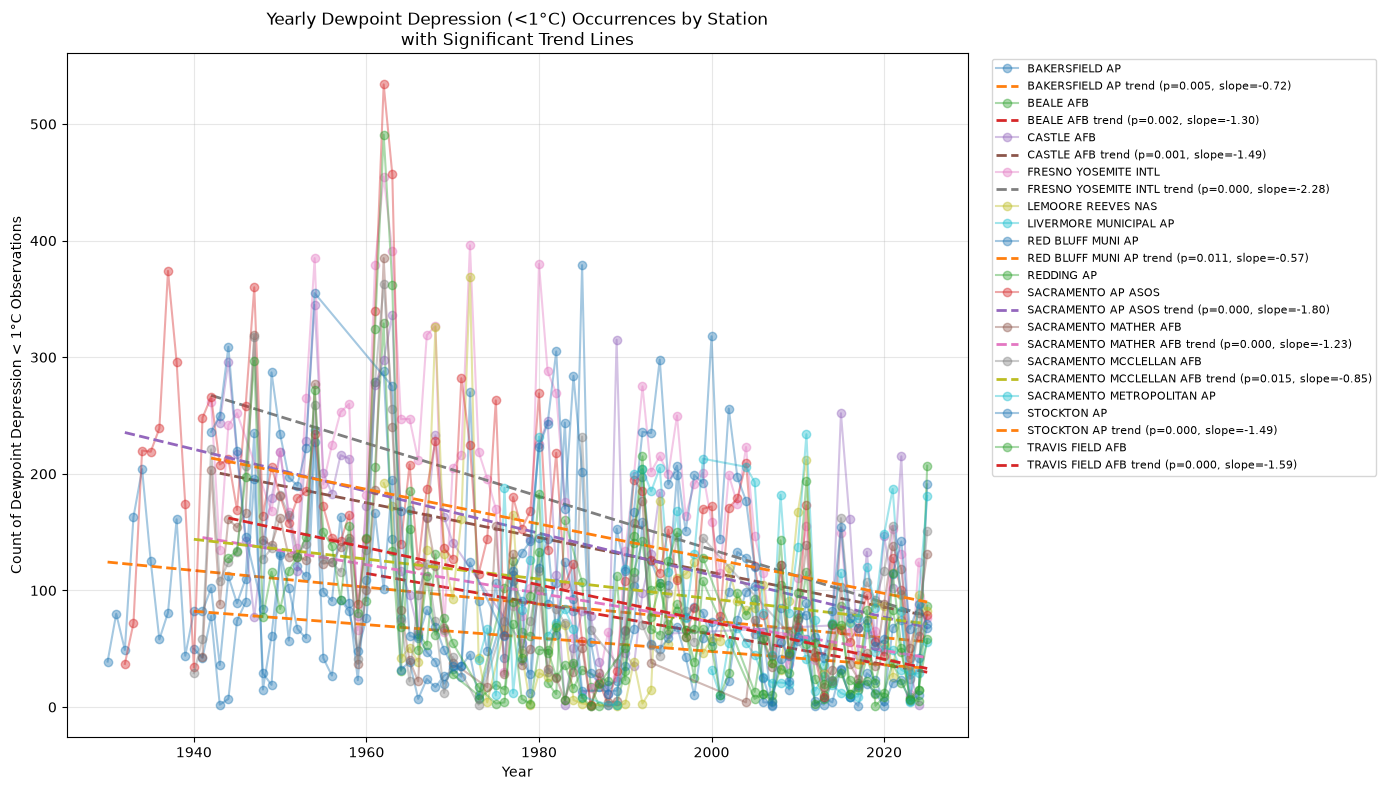

In [20]:
# Plot dewpoint depression occurrences per year for each station (CV_rows_dd_filtered_1deg)
# Fit and plot trend lines only for stations with statistically significant trends (p < 0.05)

yearly_counts = (
    CV_rows_dd_filtered_1deg.groupby(["STATION", "year"])
    .size()
    .reset_index(name="count")
)

stations = yearly_counts["STATION"].unique()

fig, ax = plt.subplots(figsize=(14, 8))

for station in stations:
    station_data = yearly_counts[yearly_counts["STATION"] == station].sort_values("year")

    if len(station_data) < 3:
        continue

    x = station_data["year"].values
    y = station_data["count"].values

    # Plot the raw yearly counts
    ax.plot(x, y, marker='o', linestyle='-', alpha=0.4, label=f"{station}")

    # Fit linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    # Only plot trend line if significant (p < 0.05)
    if p_value < 0.05:
        trend_y = slope * x + intercept
        ax.plot(x, trend_y, linestyle='--', linewidth=2,
                label=f"{station} trend (p={p_value:.3f}, slope={slope:.2f})")

ax.set_xlabel("Year")
ax.set_ylabel("Count of Dewpoint Depression < 1°C Observations")
ax.set_title("Yearly Dewpoint Depression (<1°C) Occurrences by Station\nwith Significant Trend Lines")
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

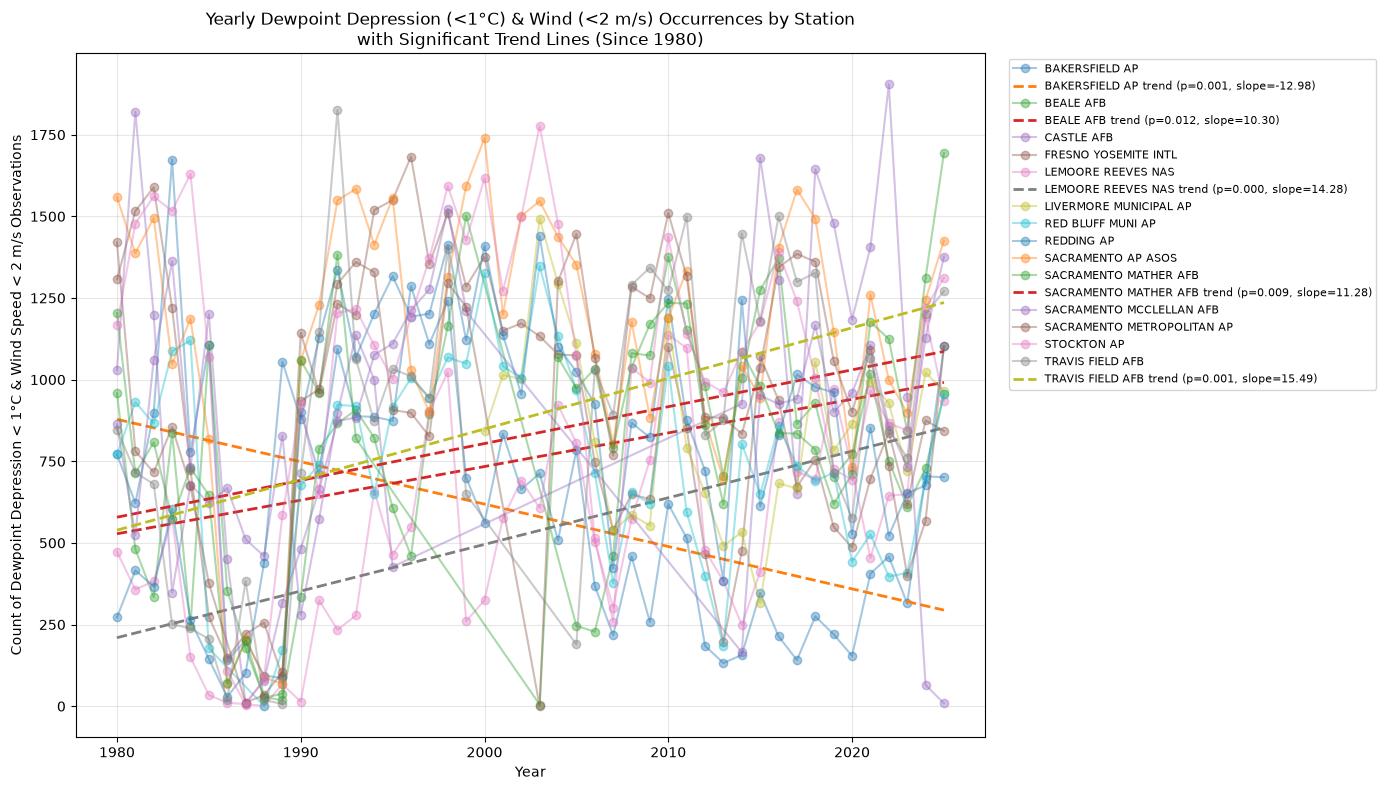

In [21]:
# Plot dewpoint depression occurrences per year for each station (CV_rows_dd_wind_filtered)
# Fit and plot trend lines only for stations with statistically significant trends (p < 0.05), since 1980

yearly_counts_wind = (
    CV_rows_dd_wind_filtered[CV_rows_dd_wind_filtered['year'] >= 1980]
    .groupby(["STATION", "year"])
    .size()
    .reset_index(name="count")
)

stations_wind = yearly_counts_wind["STATION"].unique()

fig, ax = plt.subplots(figsize=(14, 8))

for station in stations_wind:
    station_data = yearly_counts_wind[yearly_counts_wind["STATION"] == station].sort_values("year")

    if len(station_data) < 3:
        continue

    x = station_data["year"].values
    y = station_data["count"].values

    # Plot the raw yearly counts
    ax.plot(x, y, marker='o', linestyle='-', alpha=0.4, label=f"{station}")

    # Fit linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    # Only plot trend line if significant (p < 0.05)
    if p_value < 0.05:
        trend_y = slope * x + intercept
        ax.plot(x, trend_y, linestyle='--', linewidth=2,
                label=f"{station} trend (p={p_value:.3f}, slope={slope:.2f})")

ax.set_xlabel("Year")
ax.set_ylabel("Count of Dewpoint Depression < 1°C & Wind Speed < 2 m/s Observations")
ax.set_title("Yearly Dewpoint Depression (<1°C) & Wind (<2 m/s) Occurrences by Station\nwith Significant Trend Lines (Since 1980)")
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
# Compare CV_rows to CV_rows_dd_wind_filtered to determine the number of days/observations with optimal fog conditions
total_obs = CV_rows.shape[0]
optimal_obs = CV_rows_dd_wind_filtered.shape[0]

print(f"Total observations: {total_obs}")
print(f"Observations with optimal fog conditions (dewpoint depression < 4.2 & wind speed < 2 m/s): {optimal_obs}")
print(f"Percentage of optimal fog condition observations: {optimal_obs / total_obs * 100:.2f}%")

# Count unique days (based on year, month, day) with at least one optimal fog observation
optimal_days = CV_rows_dd_wind_filtered[["STATION","year", "month", "day"]].drop_duplicates().shape[0]
total_days = CV_rows[["STATION","year", "month", "day"]].drop_duplicates().shape[0]

print(f"\nTotal unique days in dataset: {total_days}")
print(f"Unique days with at least one optimal fog condition observation: {optimal_days}")
print(f"Percentage of days with optimal fog conditions: {optimal_days / total_days * 100:.2f}%")

Total observations: 2988621
Observations with optimal fog conditions (dewpoint depression < 4.2 & wind speed < 2 m/s): 806855
Percentage of optimal fog condition observations: 27.00%

Total unique days in dataset: 130885
Unique days with at least one optimal fog condition observation: 92426
Percentage of days with optimal fog conditions: 70.62%


In [23]:
# Fraction of rows in the optimal fog dataset that have visibility < 1
optimal_rows = CV_rows_dd_wind_filtered.copy()

vis_lt_1_rows = optimal_rows[optimal_rows["HourlyVisibility"] < 1].copy()
frac_rows_vis_lt_1 = vis_lt_1_rows.shape[0] / optimal_rows.shape[0]

# Compare to total unique days with optimal fog conditions
total_optimal_days = optimal_rows[["STATION", "year", "month", "day"]].drop_duplicates().shape[0]
vis_lt_1_days = vis_lt_1_rows[["STATION", "year", "month", "day"]].drop_duplicates().shape[0]
frac_days_vis_lt_1 = vis_lt_1_days / total_optimal_days

print(f"Optimal-fog rows with visibility < 1: {vis_lt_1_rows.shape[0]} / {optimal_rows.shape[0]} = {frac_rows_vis_lt_1:.2%}")
print(f"Optimal-fog days with visibility < 1: {vis_lt_1_days} / {total_optimal_days} = {frac_days_vis_lt_1:.2%}")

# Optional: also compare directly to the previously computed total optimal fog days variable, if present
if "optimal_days" in globals():
    print(f"Previous total optimal fog days variable: {optimal_days}")
    print(f"Ratio of visibility<1 days to prior optimal_days: {vis_lt_1_days / optimal_days:.2%}")

Optimal-fog rows with visibility < 1: 122631 / 806855 = 15.20%
Optimal-fog days with visibility < 1: 22697 / 92426 = 24.56%
Previous total optimal fog days variable: 92426
Ratio of visibility<1 days to prior optimal_days: 24.56%


In [24]:
# Repeat the fog analysis for only the FRESNO YOSEMITE INTL and SACRAMENTO AP ASOS stations
# use unique station names from the CV_rows dataframe
station_names = CV_rows["STATION"].unique()

#remove LIVERMORE MUNICIPAL, CASTLE AFB, and SACRAMENTO MATHER AFB from the list of stations
station_names = station_names[~np.isin(station_names, ["LIVERMORE MUNICIPAL AP", "CASTLE AFB", "SACRAMENTO MATHER AFB", "SACRAMENTO MCCLELLAN AFB"])]

# use all stations
CV_rows_selected = CV_rows[CV_rows["STATION"].isin(station_names)].copy()

# Ensure dewpoint depression exists
if "HourlyDewpointDepression" not in CV_rows_selected.columns:
    CV_rows_selected["HourlyDewpointDepression"] = (
        CV_rows_selected["HourlyDryBulbTemperature"] - CV_rows_selected["HourlyDewPointTemperature"]
    )

print("Selected station rows:", CV_rows_selected.shape)
print(CV_rows_selected["STATION"].value_counts())

# ------------------------------------------------------------------
# Optimal fog condition filter: dewpoint depression < 4.2 and wind < 2
# ------------------------------------------------------------------
CV_rows_selected_dd_wind_filtered = CV_rows_selected[
    (CV_rows_selected["HourlyDewpointDepression"] < 4.2)
    & (CV_rows_selected["HourlyWindSpeed"] < 2.0)
].copy()

CV_rows_selected_dd_wind_filtered = CV_rows_selected_dd_wind_filtered.drop_duplicates(subset=["STATION", "year", "month", "day", "hour"], keep="first")

print("\nOptimal fog condition rows (DD < 4.2 & wind < 2 m/s):", CV_rows_selected_dd_wind_filtered.shape)

CV_rows_selected_dd2_wind_filtered = CV_rows_selected[
    (CV_rows_selected["HourlyDewpointDepression"] < 2.0)
    & (CV_rows_selected["HourlyWindSpeed"] < 4.0)
].copy()

CV_rows_selected_dd2_wind_filtered = CV_rows_selected_dd2_wind_filtered.drop_duplicates(subset=["STATION", "year", "month", "day", "hour"], keep="first")

print("\nOptimal fog condition rows (DD < 2.0 & wind < 4 m/s):", CV_rows_selected_dd2_wind_filtered.shape)

CV_rows_selected_dd_wind5_filtered = CV_rows_selected[
    (CV_rows_selected["HourlyDewpointDepression"] < 2.0)
    & (CV_rows_selected["HourlyWindSpeed"] < 5.0)
].copy()

CV_rows_selected_dd_wind5_filtered = CV_rows_selected_dd_wind5_filtered.drop_duplicates(subset=["STATION", "year", "month", "day", "hour"], keep="first")

print("\nOptimal fog condition rows (DD < 2.0 & wind < 5 m/s):", CV_rows_selected_dd_wind5_filtered.shape)


CV_rows_selected_dd_wind2_filtered = CV_rows_selected[
    (CV_rows_selected["HourlyDewpointDepression"] < 1.0)
    & (CV_rows_selected["HourlyWindSpeed"] < 2.0)
].copy()

CV_rows_selected_dd_wind2_filtered = CV_rows_selected_dd_wind2_filtered.drop_duplicates(subset=["STATION", "year", "month", "day", "hour"], keep="first")

print("\nOptimal fog condition rows (DD < 1.0 & wind < 2 m/s):", CV_rows_selected_dd_wind2_filtered.shape)


# ------------------------------------------------------------------
# Visibility-based filters for multiple thresholds
# ------------------------------------------------------------------
CV_rows_selected_dd_filtered_5deg = CV_rows_selected[
    (CV_rows_selected["HourlyDewpointDepression"] < 5.0)
    # & (CV_rows_selected["HourlyVisibility"] < 1.0)
].copy()

CV_rows_selected_dd_filtered_4deg = CV_rows_selected[
    (CV_rows_selected["HourlyDewpointDepression"] < 4.0)
    # & (CV_rows_selected["HourlyVisibility"] < 1.0)
].copy()

CV_rows_selected_dd_filtered_3deg = CV_rows_selected[
    (CV_rows_selected["HourlyDewpointDepression"] < 3.0)
    # & (CV_rows_selected["HourlyVisibility"] < 1.0)
].copy()

CV_rows_selected_dd_filtered_2deg = CV_rows_selected[
    (CV_rows_selected["HourlyDewpointDepression"] < 2.0)
    # & (CV_rows_selected["HourlyVisibility"] < 1.0)
].copy()

CV_rows_selected_dd_filtered_1deg = CV_rows_selected[
    (CV_rows_selected["HourlyDewpointDepression"] < 1.0)
    # & (CV_rows_selected["HourlyVisibility"] < 1.0)
].copy()

CV_rows_selected_dd_filtered_0deg = CV_rows_selected[
    (CV_rows_selected["HourlyDewpointDepression"] <= 0.0)
    # & (CV_rows_selected["HourlyVisibility"] < 1.0)
].copy()

CV_rows_selected_dd_filtered_5deg = CV_rows_selected_dd_filtered_5deg.drop_duplicates(subset=["STATION", "year", "month", "day", "hour"], keep="first")
CV_rows_selected_dd2_wind_filtered = CV_rows_selected_dd2_wind_filtered.drop_duplicates(subset=["STATION", "year", "month", "day", "hour"], keep="first")
CV_rows_selected_dd_wind2_filtered = CV_rows_selected_dd_wind2_filtered.drop_duplicates(subset=["STATION", "year", "month", "day", "hour"], keep="first")
CV_rows_selected_dd_wind5_filtered = CV_rows_selected_dd_wind5_filtered.drop_duplicates(subset=["STATION", "year", "month", "day", "hour"], keep="first")
CV_rows_selected_dd_filtered_4deg = CV_rows_selected_dd_filtered_4deg.drop_duplicates(subset=["STATION", "year", "month", "day", "hour"], keep="first")
CV_rows_selected_dd_filtered_3deg = CV_rows_selected_dd_filtered_3deg.drop_duplicates(subset=["STATION", "year", "month", "day", "hour"], keep="first")
CV_rows_selected_dd_filtered_2deg = CV_rows_selected_dd_filtered_2deg.drop_duplicates(subset=["STATION", "year", "month", "day", "hour"], keep="first")
CV_rows_selected_dd_filtered_1deg = CV_rows_selected_dd_filtered_1deg.drop_duplicates(subset=["STATION", "year", "month", "day", "hour"], keep="first")
CV_rows_selected_dd_filtered_0deg = CV_rows_selected_dd_filtered_0deg.drop_duplicates(subset=["STATION", "year", "month", "day", "hour"], keep="first")

for name, df in {
    "CV_rows_selected_dd_filtered_5deg": CV_rows_selected_dd_filtered_5deg,
    "CV_rows_selected_dd_filtered_4deg": CV_rows_selected_dd_filtered_4deg,
    "CV_rows_selected_dd_filtered_3deg": CV_rows_selected_dd_filtered_3deg,
    "CV_rows_selected_dd_filtered_2deg": CV_rows_selected_dd_filtered_2deg,
    "CV_rows_selected_dd_filtered_1deg": CV_rows_selected_dd_filtered_1deg,
    "CV_rows_selected_dd_filtered_0deg": CV_rows_selected_dd_filtered_0deg,
}.items():
    print(f"\n{name}: {df.shape}")

# ------------------------------------------------------------------
# Station-level valley wind type summary
# ------------------------------------------------------------------
selected_valley_counts = (
    CV_rows_selected.groupby(["STATION", "valley_wind_type"])
    .size()
    .unstack(fill_value=0)
)

print("\nSelected station valley wind counts:")
print(selected_valley_counts)


Selected station rows: (2263617, 23)
STATION
BAKERSFIELD AP                315197
SACRAMENTO AP ASOS            310016
FRESNO YOSEMITE INTL          269975
TRAVIS FIELD AFB              243499
RED BLUFF MUNI AP             240329
STOCKTON AP                   214013
LEMOORE REEVES NAS            186795
BEALE AFB                     181328
REDDING AP                    157734
SACRAMENTO METROPOLITAN AP    144731
Name: count, dtype: int64

Optimal fog condition rows (DD < 4.2 & wind < 2 m/s): (506978, 23)

Optimal fog condition rows (DD < 2.0 & wind < 4 m/s): (559244, 23)

Optimal fog condition rows (DD < 2.0 & wind < 5 m/s): (604325, 23)

Optimal fog condition rows (DD < 1.0 & wind < 2 m/s): (132907, 23)

CV_rows_selected_dd_filtered_5deg: (1350749, 23)

CV_rows_selected_dd_filtered_4deg: (1240542, 23)

CV_rows_selected_dd_filtered_3deg: (1006171, 23)

CV_rows_selected_dd_filtered_2deg: (680326, 23)

CV_rows_selected_dd_filtered_1deg: (277073, 23)

CV_rows_selected_dd_filtered_0deg: (13

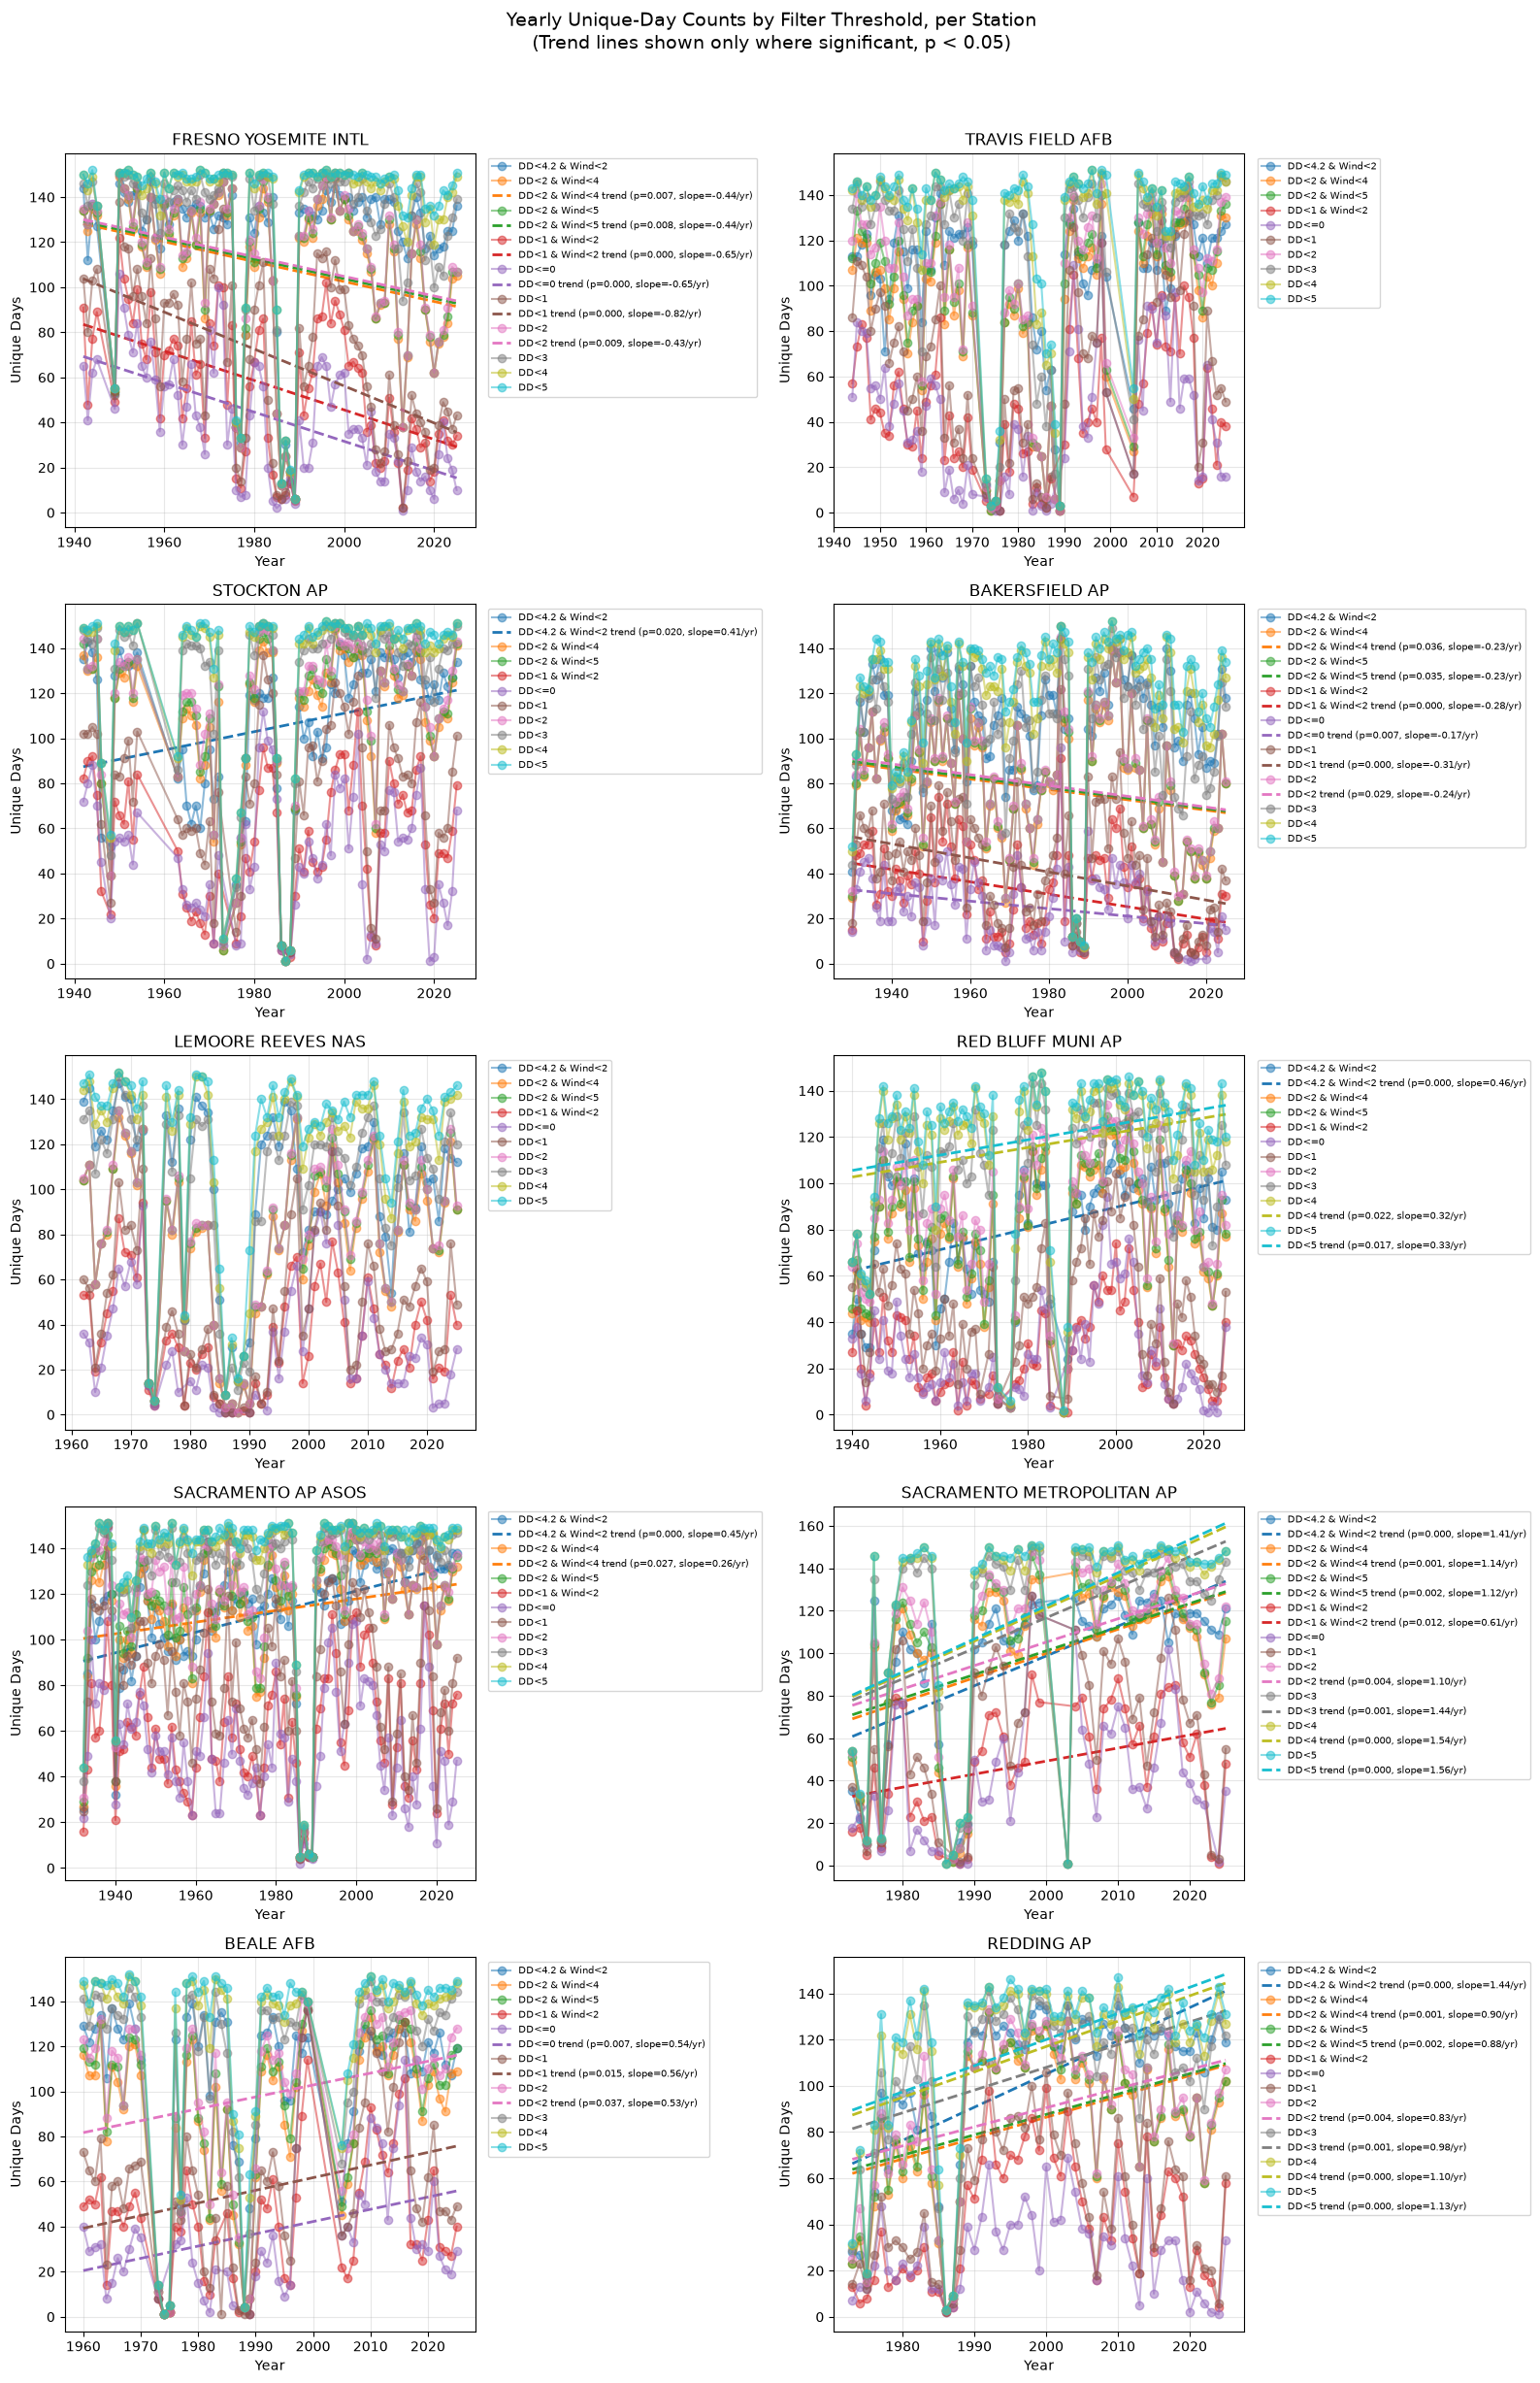

In [25]:
# Individual per-station plots: yearly unique-day counts for multiple dewpoint-depression/visibility
# filters, with significant (p < 0.05) trend lines only

filters_to_plot = {
    "DD<4.2 & Wind<2": CV_rows_selected_dd_wind_filtered,
    "DD<2 & Wind<4": CV_rows_selected_dd2_wind_filtered,
    "DD<2 & Wind<5": CV_rows_selected_dd_wind5_filtered,
    "DD<1 & Wind<2": CV_rows_selected_dd_wind2_filtered,
    "DD<=0": CV_rows_selected_dd_filtered_0deg,
    "DD<1": CV_rows_selected_dd_filtered_1deg,
    "DD<2": CV_rows_selected_dd_filtered_2deg,
    "DD<3": CV_rows_selected_dd_filtered_3deg,
    "DD<4": CV_rows_selected_dd_filtered_4deg,
    "DD<5": CV_rows_selected_dd_filtered_5deg,
}

colors = plt.cm.tab10(np.linspace(0, 1, len(filters_to_plot)))

n_stations = len(station_names)
n_cols = 2
n_rows = int(np.ceil(n_stations / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows), sharex=False)
axes = axes.flatten()

for i, station in enumerate(station_names):
    ax = axes[i]

    for (label, df), color in zip(filters_to_plot.items(), colors):
        station_df = df[df["STATION"] == station]

        # unique days per year
        yearly_days = (
            station_df[["year", "month", "day"]]
            .drop_duplicates()
            .groupby("year")
            .size()
            .reset_index(name="count")
            .sort_values("year")
        )

        if len(yearly_days) < 3:
            continue

        x = yearly_days["year"].to_numpy()
        y = yearly_days["count"].to_numpy()

        ax.plot(x, y, marker="o", linestyle="-", alpha=0.5, color=color, label=label)

        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

        if np.isfinite(p_value) and p_value < 0.05:
            trend_y = slope * x + intercept
            ax.plot(
                x, trend_y, linestyle="--", linewidth=2, color=color,
                label=f"{label} trend (p={p_value:.3f}, slope={slope:.2f}/yr)"
            )

    ax.set_title(station)
    ax.set_xlabel("Year")
    ax.set_ylabel("Unique Days")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.02, 1))

for j in range(n_stations, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    "Yearly Unique-Day Counts by Filter Threshold, per Station\n"
    "(Trend lines shown only where significant, p < 0.05)",
    fontsize=14,
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

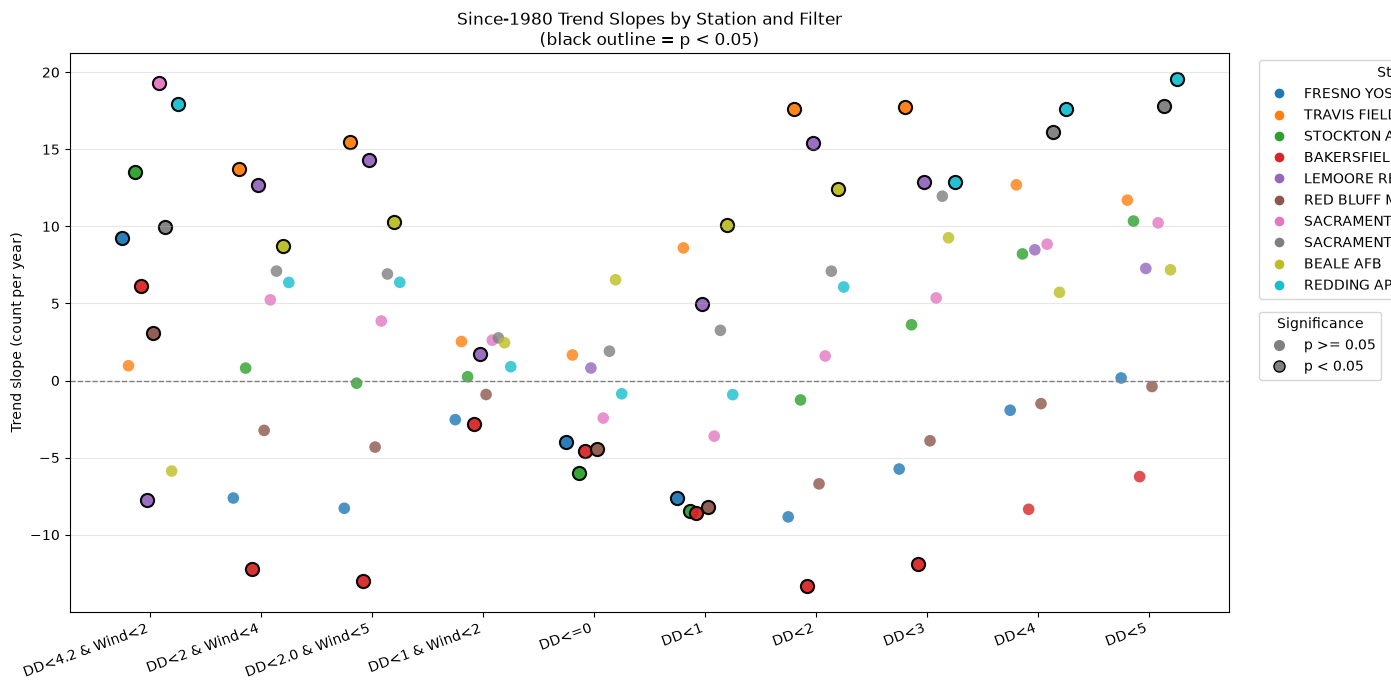

,filter,STATION,slope_per_year,p_value,significant
53,DD<1,BAKERSFIELD AP,-8.611101,0.000037,True
55,DD<1,RED BLUFF MUNI AP,-8.190452,0.005597,True
50,DD<1,FRESNO YOSEMITE INTL,-7.626087,0.007843,True
58,DD<1,BEALE AFB,10.080204,0.010444,True
52,DD<1,STOCKTON AP,-8.464784,0.017034,True
54,DD<1,LEMOORE REEVES NAS,4.995819,0.026689,True
51,DD<1,TRAVIS FIELD AFB,8.604247,0.090526,False
57,DD<1,SACRAMENTO METROPOLITAN AP,3.256169,0.329974,False
56,DD<1,SACRAMENTO AP ASOS,-3.605735,0.351965,False
59,DD<1,REDDING AP,-0.913599,0.757581,False


In [26]:
# Trend summary plot since 1980:
# one point per (station, filter) showing slope of yearly counts vs year.
# Station = color, significant trend (p < 0.05) = black outline.

filters_for_trend = {
    "DD<4.2 & Wind<2": CV_rows_selected_dd_wind_filtered,
    "DD<2 & Wind<4": CV_rows_selected_dd2_wind_filtered,
    "DD<2.0 & Wind<5": CV_rows_selected_dd_wind5_filtered,
    "DD<1 & Wind<2": CV_rows_selected_dd_wind2_filtered,
    "DD<=0": CV_rows_selected_dd_filtered_0deg,
    "DD<1": CV_rows_selected_dd_filtered_1deg,
    "DD<2": CV_rows_selected_dd_filtered_2deg,
    "DD<3": CV_rows_selected_dd_filtered_3deg,
    "DD<4": CV_rows_selected_dd_filtered_4deg,
    "DD<5": CV_rows_selected_dd_filtered_5deg,
}

trend_points = []

for filter_name, df_filter in filters_for_trend.items():
    yearly = (
        df_filter[df_filter["year"] >= 1980]
        .groupby(["STATION", "year"])
        .size()
        .reset_index(name="count")
    )

    for st in station_names:
        sd = yearly[yearly["STATION"] == st].sort_values("year")
        if len(sd) < 3:
            continue

        x = sd["year"].to_numpy()
        y = sd["count"].to_numpy()
        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

        trend_points.append(
            {
                "filter": filter_name,
                "STATION": st,
                "slope_per_year": slope,
                "p_value": p_value,
                "significant": bool(np.isfinite(p_value) and (p_value < 0.05)),
            }
        )

trend_points_df = pd.DataFrame(trend_points)

# Plot
fig, ax = plt.subplots(figsize=(14, 7))

filter_order = list(filters_for_trend.keys())
x_map = {f: i for i, f in enumerate(filter_order)}

station_colors = dict(zip(station_names, plt.cm.tab10(np.linspace(0, 1, len(station_names)))))
offsets = np.linspace(-0.25, 0.25, len(station_names))
station_offset = dict(zip(station_names, offsets))

for st in station_names:
    sub = trend_points_df[trend_points_df["STATION"] == st].copy()
    if sub.empty:
        continue

    sub["x"] = sub["filter"].map(x_map).astype(float) + station_offset[st]

    # non-significant points
    ns = sub[~sub["significant"]]
    ax.scatter(
        ns["x"], ns["slope_per_year"],
        s=70, color=station_colors[st], alpha=0.8,
        edgecolors="none"
    )

    # significant points with black outline
    sg = sub[sub["significant"]]
    ax.scatter(
        sg["x"], sg["slope_per_year"],
        s=90, color=station_colors[st], alpha=0.95,
        edgecolors="black", linewidths=1.5
    )

# style
ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xticks(range(len(filter_order)))
ax.set_xticklabels(filter_order, rotation=20, ha="right")
ax.set_ylabel("Trend slope (count per year)")
ax.set_title("Since-1980 Trend Slopes by Station and Filter\n(black outline = p < 0.05)")
ax.grid(True, axis="y", alpha=0.3)

# legend for station colors
station_handles = [
    plt.Line2D([0], [0], marker="o", color="w", label=st,
               markerfacecolor=station_colors[st], markersize=8)
    for st in station_names
]
legend1 = ax.legend(handles=station_handles, title="Station", loc="upper left", bbox_to_anchor=(1.02, 1))
ax.add_artist(legend1)

# legend for significance style
sig_handles = [
    plt.Line2D([0], [0], marker="o", color="w", label="p >= 0.05",
               markerfacecolor="gray", markeredgecolor="none", markersize=8),
    plt.Line2D([0], [0], marker="o", color="w", label="p < 0.05",
               markerfacecolor="gray", markeredgecolor="black", markersize=8),
]
ax.legend(handles=sig_handles, title="Significance", loc="upper left", bbox_to_anchor=(1.02, 0.55))

plt.tight_layout()
plt.show()

trend_points_df.sort_values(["filter", "p_value"]).head(20)

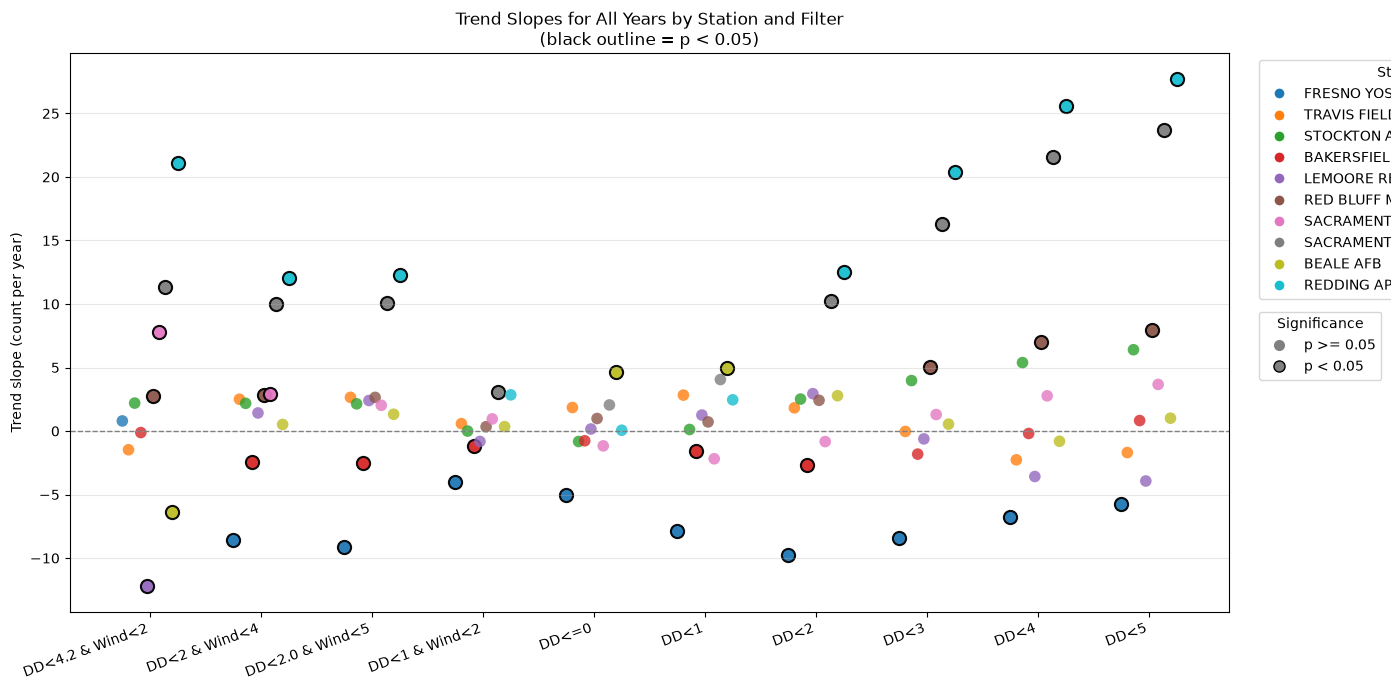

,filter,STATION,slope_per_year,p_value,significant
50,DD<1,FRESNO YOSEMITE INTL,-7.844896,1.127329e-08,True
53,DD<1,BAKERSFIELD AP,-1.580521,1.381604e-02,True
58,DD<1,BEALE AFB,4.997087,1.716660e-02,True
56,DD<1,SACRAMENTO AP ASOS,-2.184655,8.088772e-02,False
57,DD<1,SACRAMENTO METROPOLITAN AP,4.053499,1.175555e-01,False
51,DD<1,TRAVIS FIELD AFB,2.828750,1.237773e-01,False
59,DD<1,REDDING AP,2.458071,2.929073e-01,False
54,DD<1,LEMOORE REEVES NAS,1.258967,3.572467e-01,False
55,DD<1,RED BLUFF MUNI AP,0.717284,4.683386e-01,False
52,DD<1,STOCKTON AP,0.122032,9.344068e-01,False


In [27]:
# Trend summary plot for all years
# one point per (station, filter) showing slope of yearly counts vs year.
# Station = color, significant trend (p < 0.05) = black outline.

filters_for_trend = {
    "DD<4.2 & Wind<2": CV_rows_selected_dd_wind_filtered,
    "DD<2 & Wind<4": CV_rows_selected_dd2_wind_filtered,
    "DD<2.0 & Wind<5": CV_rows_selected_dd_wind5_filtered,
    "DD<1 & Wind<2": CV_rows_selected_dd_wind2_filtered,
    "DD<=0": CV_rows_selected_dd_filtered_0deg,
    "DD<1": CV_rows_selected_dd_filtered_1deg,
    "DD<2": CV_rows_selected_dd_filtered_2deg,
    "DD<3": CV_rows_selected_dd_filtered_3deg,
    "DD<4": CV_rows_selected_dd_filtered_4deg,
    "DD<5": CV_rows_selected_dd_filtered_5deg,
}

trend_points = []

for filter_name, df_filter in filters_for_trend.items():
    yearly = (
        df_filter
        .groupby(["STATION", "year"])
        .size()
        .reset_index(name="count")
    )

    for st in station_names:
        sd = yearly[yearly["STATION"] == st].sort_values("year")
        if len(sd) < 3:
            continue

        x = sd["year"].to_numpy()
        y = sd["count"].to_numpy()
        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

        trend_points.append(
            {
                "filter": filter_name,
                "STATION": st,
                "slope_per_year": slope,
                "p_value": p_value,
                "significant": bool(np.isfinite(p_value) and (p_value < 0.05)),
            }
        )

trend_points_df = pd.DataFrame(trend_points)

# Plot
fig, ax = plt.subplots(figsize=(14, 7))

filter_order = list(filters_for_trend.keys())
x_map = {f: i for i, f in enumerate(filter_order)}

station_colors = dict(zip(station_names, plt.cm.tab10(np.linspace(0, 1, len(station_names)))))
offsets = np.linspace(-0.25, 0.25, len(station_names))
station_offset = dict(zip(station_names, offsets))

for st in station_names:
    sub = trend_points_df[trend_points_df["STATION"] == st].copy()
    if sub.empty:
        continue

    sub["x"] = sub["filter"].map(x_map).astype(float) + station_offset[st]

    # non-significant points
    ns = sub[~sub["significant"]]
    ax.scatter(
        ns["x"], ns["slope_per_year"],
        s=70, color=station_colors[st], alpha=0.8,
        edgecolors="none"
    )

    # significant points with black outline
    sg = sub[sub["significant"]]
    ax.scatter(
        sg["x"], sg["slope_per_year"],
        s=90, color=station_colors[st], alpha=0.95,
        edgecolors="black", linewidths=1.5
    )

# style
ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xticks(range(len(filter_order)))
ax.set_xticklabels(filter_order, rotation=20, ha="right")
ax.set_ylabel("Trend slope (count per year)")
ax.set_title("Trend Slopes for All Years by Station and Filter\n(black outline = p < 0.05)")
ax.grid(True, axis="y", alpha=0.3)

# legend for station colors
station_handles = [
    plt.Line2D([0], [0], marker="o", color="w", label=st,
               markerfacecolor=station_colors[st], markersize=8)
    for st in station_names
]
legend1 = ax.legend(handles=station_handles, title="Station", loc="upper left", bbox_to_anchor=(1.02, 1))
ax.add_artist(legend1)

# legend for significance style
sig_handles = [
    plt.Line2D([0], [0], marker="o", color="w", label="p >= 0.05",
               markerfacecolor="gray", markeredgecolor="none", markersize=8),
    plt.Line2D([0], [0], marker="o", color="w", label="p < 0.05",
               markerfacecolor="gray", markeredgecolor="black", markersize=8),
]
ax.legend(handles=sig_handles, title="Significance", loc="upper left", bbox_to_anchor=(1.02, 0.55))

plt.tight_layout()
plt.show()

trend_points_df.sort_values(["filter", "p_value"]).head(20)

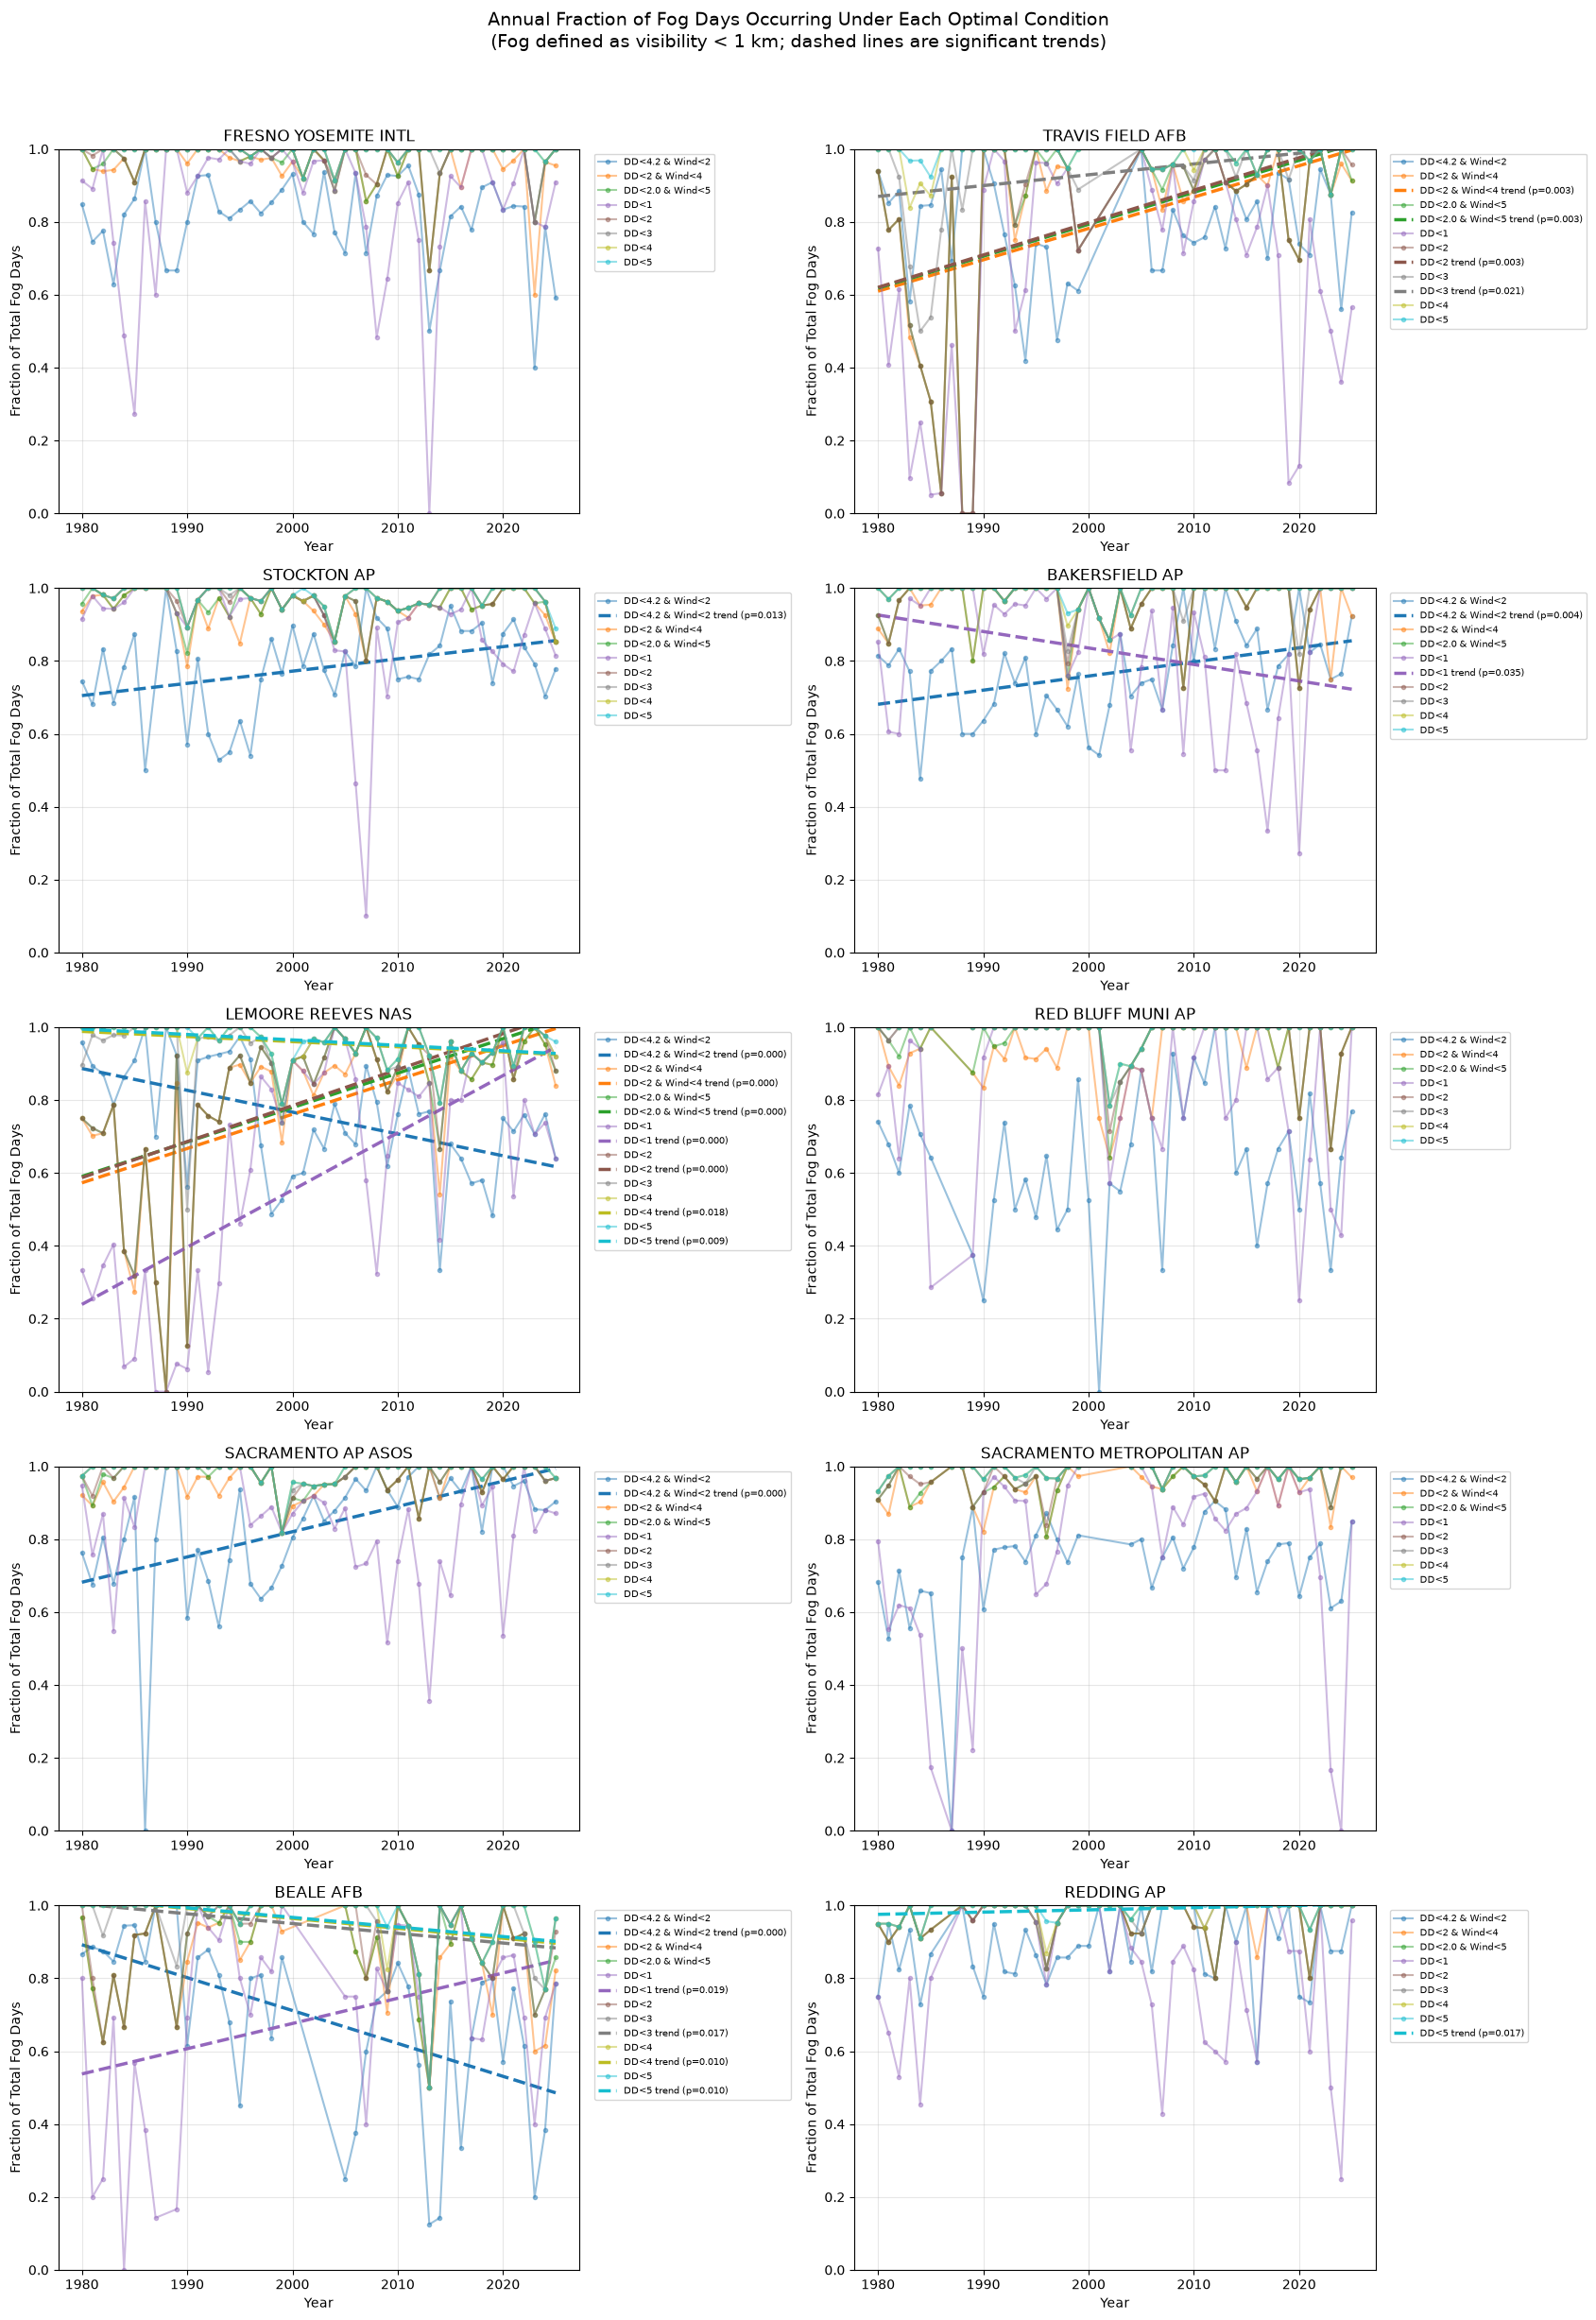

Fog-day fractions:


,STATION,year,total_fog_days,criterion_fog_days,fog_fraction,criterion
1314,BAKERSFIELD AP,1980,27,23.0,0.851852,DD<1
1752,BAKERSFIELD AP,1980,27,25.0,0.925926,DD<2
438,BAKERSFIELD AP,1980,27,24.0,0.888889,DD<2 & Wind<4
876,BAKERSFIELD AP,1980,27,25.0,0.925926,DD<2.0 & Wind<5
2190,BAKERSFIELD AP,1980,27,27.0,1.000000,DD<3
...,...,...,...,...,...,...
1313,TRAVIS FIELD AFB,2025,23,21.0,0.913043,DD<2.0 & Wind<5
2627,TRAVIS FIELD AFB,2025,23,23.0,1.000000,DD<3
3065,TRAVIS FIELD AFB,2025,23,23.0,1.000000,DD<4
437,TRAVIS FIELD AFB,2025,23,19.0,0.826087,DD<4.2 & Wind<2



Significant trends:


,STATION,criterion,slope_per_year,p_value,significant
24,BAKERSFIELD AP,DD<4.2 & Wind<2,0.003874,3.648699e-03,True
27,BAKERSFIELD AP,DD<1,-0.004522,3.480788e-02,True
64,BEALE AFB,DD<4.2 & Wind<2,-0.009029,2.851005e-04,True
70,BEALE AFB,DD<4,-0.002719,9.720182e-03,True
71,BEALE AFB,DD<5,-0.002629,1.040247e-02,True
69,BEALE AFB,DD<3,-0.002676,1.666473e-02,True
67,BEALE AFB,DD<1,0.006924,1.900129e-02,True
35,LEMOORE REEVES NAS,DD<1,0.015700,3.106149e-07,True
36,LEMOORE REEVES NAS,DD<2,0.009880,2.715266e-05,True
33,LEMOORE REEVES NAS,DD<2 & Wind<4,0.009412,5.432501e-05,True


In [28]:
# Fog days per year and station under each optimal-condition criterion,
# expressed as a fraction of total fog days (visibility < 1 km).
# Significant linear trends are plotted for each station and criterion.

criteria = {
    "DD<4.2 & Wind<2": CV_rows_selected_dd_wind_filtered,
    "DD<2 & Wind<4": CV_rows_selected_dd2_wind_filtered,
    "DD<2.0 & Wind<5": CV_rows_selected_dd_wind5_filtered,
    "DD<1": CV_rows_selected_dd_filtered_1deg,
    "DD<2": CV_rows_selected_dd_filtered_2deg,
    "DD<3": CV_rows_selected_dd_filtered_3deg,
    "DD<4": CV_rows_selected_dd_filtered_4deg,
    "DD<5": CV_rows_selected_dd_filtered_5deg,
}

def daily_fog_counts(df):
    fog = df[
        (df["HourlyVisibility"] < 1)
        & (df["year"] >= 1980)
    ][["STATION", "year", "month", "day"]].drop_duplicates()

    return (
        fog.groupby(["STATION", "year"])
        .size()
        .reset_index(name="fog_days")
    )

# Total fog days per station and year
total_fog_days = daily_fog_counts(CV_rows_selected)
total_fog_days = total_fog_days.rename(columns={"fog_days": "total_fog_days"})

records = []

for criterion, criterion_df in criteria.items():
    criterion_fog_days = daily_fog_counts(criterion_df)
    criterion_fog_days = criterion_fog_days.rename(
        columns={"fog_days": "criterion_fog_days"}
    )

    result = pd.merge(
        total_fog_days,
        criterion_fog_days,
        on=["STATION", "year"],
        how="left",
    )

    result["criterion_fog_days"] = result["criterion_fog_days"].fillna(0)
    result["fog_fraction"] = (
        result["criterion_fog_days"] / result["total_fog_days"]
    )
    result["criterion"] = criterion
    records.append(result)

fog_fraction_by_criterion = pd.concat(records, ignore_index=True)

# Individual plot for each station
n_cols = 2
n_rows = int(np.ceil(len(station_names) / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(17, 5 * n_rows), sharex=False
)
axes = np.atleast_1d(axes).flatten()

colors = plt.cm.tab10(np.linspace(0, 1, len(criteria)))

trend_records = []

for ax, station in zip(axes, station_names):
    station_data = fog_fraction_by_criterion[
        fog_fraction_by_criterion["STATION"] == station
    ]

    for (criterion, criterion_data), color in zip(
        station_data.groupby("criterion", sort=False), colors
    ):
        criterion_data = criterion_data.sort_values("year")

        if len(criterion_data) < 3:
            continue

        x = criterion_data["year"].to_numpy()
        y = criterion_data["fog_fraction"].to_numpy()

        ax.plot(
            x, y, marker="o", markersize=3, alpha=0.45,
            color=color, label=criterion
        )

        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
        significant = np.isfinite(p_value) and p_value < 0.05

        trend_records.append({
            "STATION": station,
            "criterion": criterion,
            "slope_per_year": slope,
            "p_value": p_value,
            "significant": significant,
        })

        if significant:
            ax.plot(
                x, slope * x + intercept,
                linestyle="--", linewidth=2.5, color=color,
                label=f"{criterion} trend (p={p_value:.3f})"
            )

    ax.set_title(station)
    ax.set_xlabel("Year")
    ax.set_ylabel("Fraction of Total Fog Days")
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.02, 1))

for ax in axes[len(station_names):]:
    ax.set_visible(False)

fig.suptitle(
    "Annual Fraction of Fog Days Occurring Under Each Optimal Condition\n"
    "(Fog defined as visibility < 1 km; dashed lines are significant trends)",
    fontsize=14,
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

fog_trend_summary = (
    pd.DataFrame(trend_records)
    .sort_values(["STATION", "p_value"])
)

print("Fog-day fractions:")
display(fog_fraction_by_criterion.sort_values(["STATION", "year", "criterion"]))

print("\nSignificant trends:")
display(
    fog_trend_summary[fog_trend_summary["significant"]]
)

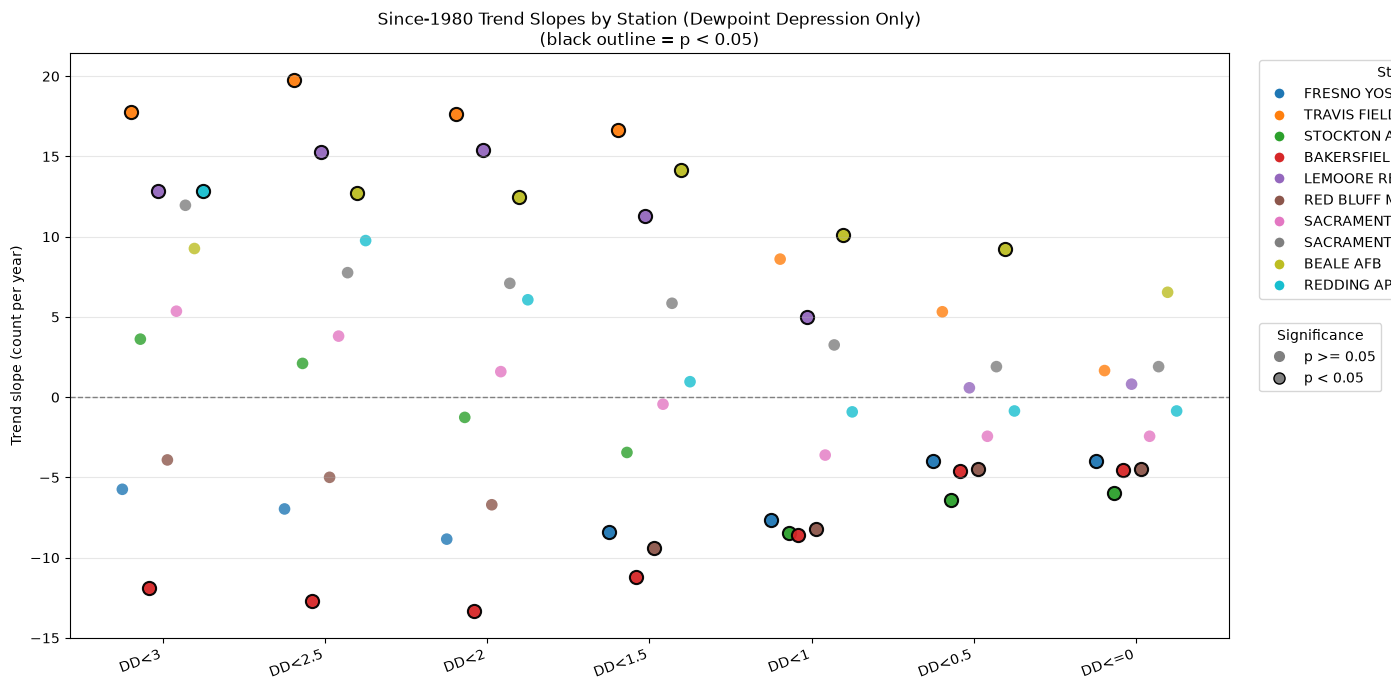

,filter,STATION,slope_per_year,p_value,significant
53,DD<0.5,BAKERSFIELD AP,-4.586751,0.000421,True
52,DD<0.5,STOCKTON AP,-6.379543,0.003912,True
50,DD<0.5,FRESNO YOSEMITE INTL,-3.949505,0.004610,True
55,DD<0.5,RED BLUFF MUNI AP,-4.470480,0.026731,True
58,DD<0.5,BEALE AFB,9.207586,0.028176,True
51,DD<0.5,TRAVIS FIELD AFB,5.323852,0.263775,False
56,DD<0.5,SACRAMENTO AP ASOS,-2.433796,0.323947,False
57,DD<0.5,SACRAMENTO METROPOLITAN AP,1.904514,0.448691,False
59,DD<0.5,REDDING AP,-0.858279,0.452554,False
54,DD<0.5,LEMOORE REEVES NAS,0.586387,0.789863,False


In [29]:
# Dewpoint-depression-only trend summary plot since 1980
# Thresholds: <3, <2.5, <2, <1.5, <1, <0.5, and <=0

dd_thresholds = [3.0, 2.5, 2.0, 1.5, 1.0, 0.5]

filters_dd_only = {
    f"DD<{thr:g}": CV_rows_selected[
        CV_rows_selected["HourlyDewpointDepression"] < thr
    ].drop_duplicates(subset=["STATION", "year", "month", "day", "hour"], keep="first")
    for thr in dd_thresholds
}

filters_dd_only["DD<=0"] = CV_rows_selected[
    CV_rows_selected["HourlyDewpointDepression"] <= 0
].drop_duplicates(subset=["STATION", "year", "month", "day", "hour"], keep="first")

trend_points_dd_only = []

for filter_name, df_filter in filters_dd_only.items():
    yearly = (
        df_filter[df_filter["year"] >= 1980]
        .groupby(["STATION", "year"])
        .size()
        .reset_index(name="count")
    )

    for st in station_names:
        sd = yearly[yearly["STATION"] == st].sort_values("year")
        if len(sd) < 3:
            continue

        x = sd["year"].to_numpy()
        y = sd["count"].to_numpy()
        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

        trend_points_dd_only.append(
            {
                "filter": filter_name,
                "STATION": st,
                "slope_per_year": slope,
                "p_value": p_value,
                "significant": bool(np.isfinite(p_value) and (p_value < 0.05)),
            }
        )

trend_points_dd_only_df = pd.DataFrame(trend_points_dd_only)

# Plot (same style as prior trend summary)
fig, ax = plt.subplots(figsize=(14, 7))

filter_order = list(filters_dd_only.keys())
x_map = {f: i for i, f in enumerate(filter_order)}

station_colors = dict(zip(station_names, plt.cm.tab10(np.linspace(0, 1, len(station_names)))))
offsets = np.linspace(-0.25, 0.25, len(station_names))
station_offset = dict(zip(station_names, offsets))

for st in station_names:
    sub = trend_points_dd_only_df[trend_points_dd_only_df["STATION"] == st].copy()
    if sub.empty:
        continue

    sub["x"] = sub["filter"].map(x_map).astype(float) + station_offset[st]

    ns = sub[~sub["significant"]]
    ax.scatter(
        ns["x"], ns["slope_per_year"],
        s=70, color=station_colors[st], alpha=0.8, edgecolors="none"
    )

    sg = sub[sub["significant"]]
    ax.scatter(
        sg["x"], sg["slope_per_year"],
        s=90, color=station_colors[st], alpha=0.95, edgecolors="black", linewidths=1.5
    )

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xticks(range(len(filter_order)))
ax.set_xticklabels(filter_order, rotation=20, ha="right")
ax.set_ylabel("Trend slope (count per year)")
ax.set_title("Since-1980 Trend Slopes by Station (Dewpoint Depression Only)\n(black outline = p < 0.05)")
ax.grid(True, axis="y", alpha=0.3)

station_handles = [
    plt.Line2D([0], [0], marker="o", color="w", label=st,
               markerfacecolor=station_colors[st], markersize=8)
    for st in station_names
]
legend1 = ax.legend(handles=station_handles, title="Station", loc="upper left", bbox_to_anchor=(1.02, 1))
ax.add_artist(legend1)

sig_handles = [
    plt.Line2D([0], [0], marker="o", color="w", label="p >= 0.05",
               markerfacecolor="gray", markeredgecolor="none", markersize=8),
    plt.Line2D([0], [0], marker="o", color="w", label="p < 0.05",
               markerfacecolor="gray", markeredgecolor="black", markersize=8),
]
ax.legend(handles=sig_handles, title="Significance", loc="upper left", bbox_to_anchor=(1.02, 0.55))

plt.tight_layout()
plt.show()

trend_points_dd_only_df.sort_values(["filter", "p_value"]).head(30)

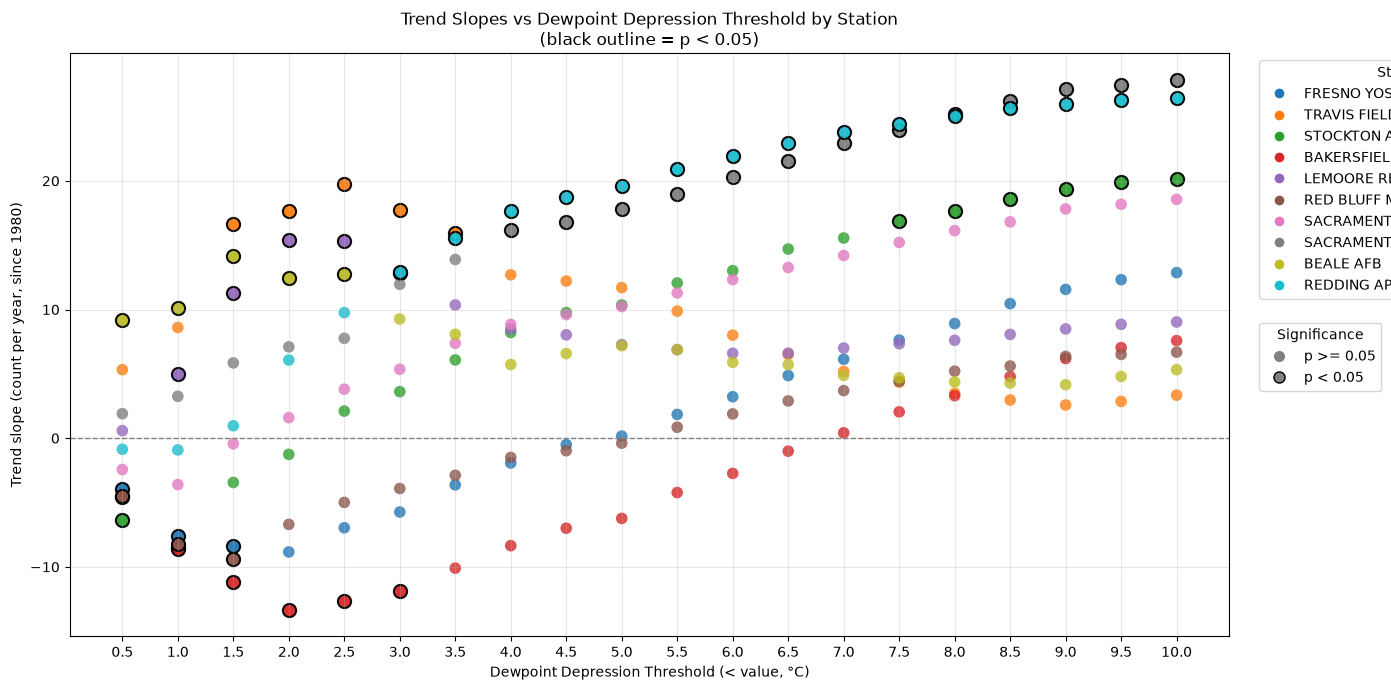

,threshold,STATION,slope_per_year,p_value,significant
3,0.5,BAKERSFIELD AP,-4.586751,0.000421,True
2,0.5,STOCKTON AP,-6.379543,0.003912,True
0,0.5,FRESNO YOSEMITE INTL,-3.949505,0.004610,True
5,0.5,RED BLUFF MUNI AP,-4.470480,0.026731,True
8,0.5,BEALE AFB,9.207586,0.028176,True
...,...,...,...,...,...
194,10.0,LEMOORE REEVES NAS,9.029726,0.317502,False
195,10.0,RED BLUFF MUNI AP,6.685283,0.347733,False
193,10.0,BAKERSFIELD AP,7.581314,0.378509,False
198,10.0,BEALE AFB,5.322492,0.506559,False


In [30]:
# # Scatterplot: DD threshold on x-axis (0 to 10, increments of 0.5), yearly count trend slope on y-axis
# # One point per (station, threshold), significant trends (p < 0.05, since 1980) outlined in black

# dd_thresholds_full = np.arange(0.5, 10.5, 0.5)

# trend_points_dd_scatter = []

# for thr in dd_thresholds_full:
#     df_filter = CV_rows_selected[
#         CV_rows_selected["HourlyDewpointDepression"] < thr
#     ].drop_duplicates(subset=["STATION", "year", "month", "day", "hour"], keep="first")

#     yearly = (
#         df_filter[df_filter["year"] >= 1980]
#         .groupby(["STATION", "year"])
#         .size()
#         .reset_index(name="count")
#     )

#     for st in station_names:
#         sd = yearly[yearly["STATION"] == st].sort_values("year")
#         if len(sd) < 3:
#             continue

#         x = sd["year"].to_numpy()
#         y = sd["count"].to_numpy()
#         slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

#         trend_points_dd_scatter.append({
#             "threshold": thr,
#             "STATION": st,
#             "slope_per_year": slope,
#             "p_value": p_value,
#             "significant": bool(np.isfinite(p_value) and (p_value < 0.05)),
#         })

# trend_points_dd_scatter_df = pd.DataFrame(trend_points_dd_scatter)

# # Plot
# fig, ax = plt.subplots(figsize=(14, 7))

# station_colors = dict(zip(station_names, plt.cm.tab10(np.linspace(0, 1, len(station_names)))))

# for st in station_names:
#     sub = trend_points_dd_scatter_df[trend_points_dd_scatter_df["STATION"] == st]
#     if sub.empty:
#         continue

#     ns = sub[~sub["significant"]]
#     ax.scatter(
#         ns["threshold"], ns["slope_per_year"],
#         s=70, color=station_colors[st], alpha=0.8, edgecolors="none"
#     )

#     sg = sub[sub["significant"]]
#     ax.scatter(
#         sg["threshold"], sg["slope_per_year"],
#         s=90, color=station_colors[st], alpha=0.95,
#         edgecolors="black", linewidths=1.5
#     )

# ax.axhline(0, color="gray", linestyle="--", linewidth=1)
# ax.set_xticks(dd_thresholds_full)
# ax.set_xlabel("Dewpoint Depression Threshold (< value, °C)")
# ax.set_ylabel("Trend slope (count per year, since 1980)")
# ax.set_title("Trend Slopes vs Dewpoint Depression Threshold by Station\n(black outline = p < 0.05)")
# ax.grid(True, alpha=0.3)

# station_handles = [
#     plt.Line2D([0], [0], marker="o", color="w", label=st,
#                markerfacecolor=station_colors[st], markersize=8)
#     for st in station_names
# ]
# legend1 = ax.legend(handles=station_handles, title="Station", loc="upper left", bbox_to_anchor=(1.02, 1))
# ax.add_artist(legend1)

# sig_handles = [
#     plt.Line2D([0], [0], marker="o", color="w", label="p >= 0.05",
#                markerfacecolor="gray", markeredgecolor="none", markersize=8),
#     plt.Line2D([0], [0], marker="o", color="w", label="p < 0.05",
#                markerfacecolor="gray", markeredgecolor="black", markersize=8),
# ]
# ax.legend(handles=sig_handles, title="Significance", loc="upper left", bbox_to_anchor=(1.02, 0.55))

# plt.tight_layout()
# plt.show()

# trend_points_dd_scatter_df.sort_values(["threshold", "p_value"])

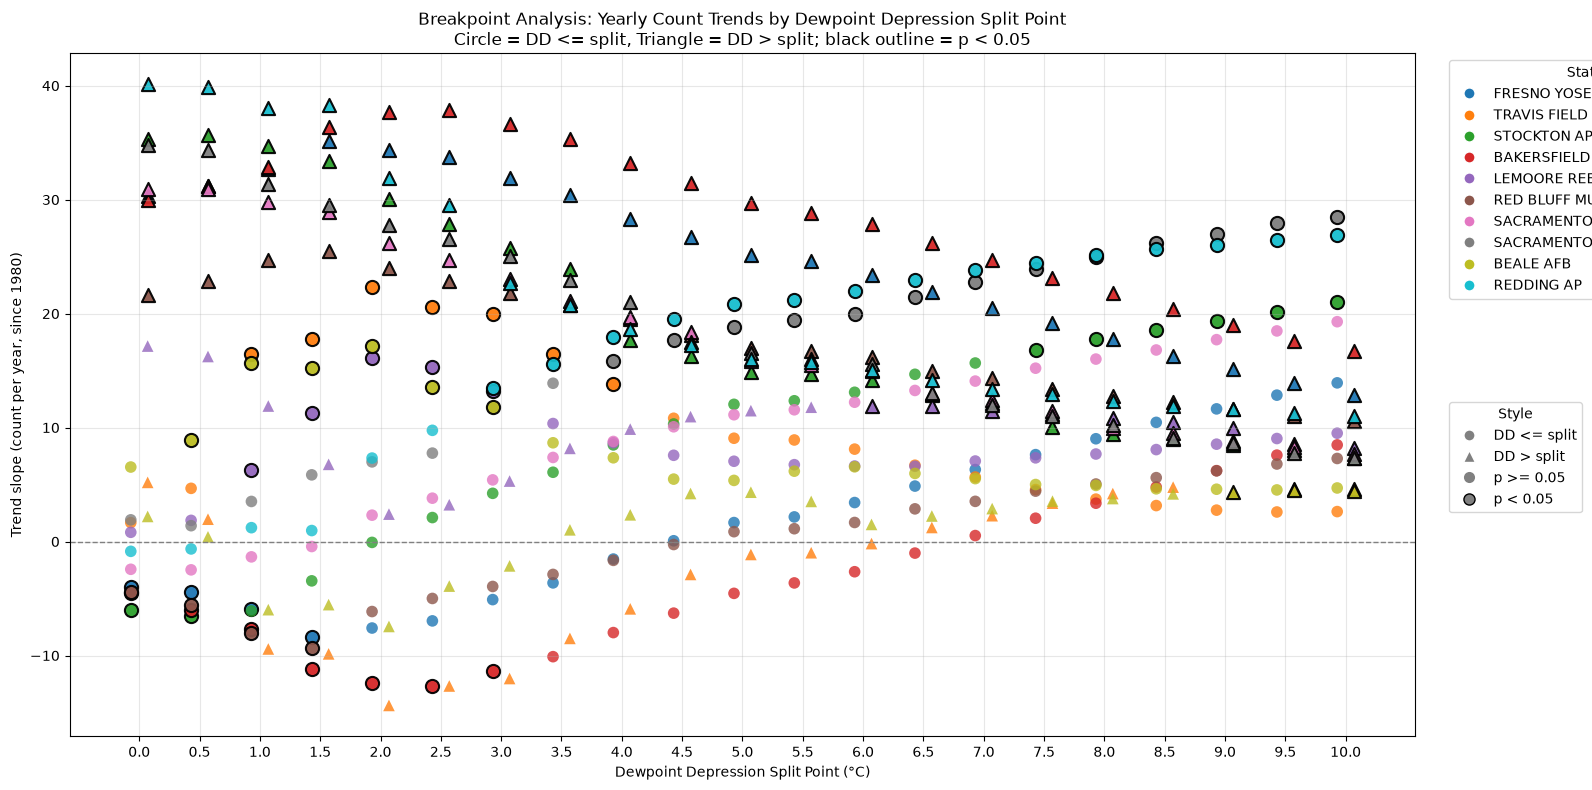

,split,side,STATION,slope_per_year,p_value,significant
3,0.0,<=,BAKERSFIELD AP,-4.552278,0.000456,True
0,0.0,<=,FRESNO YOSEMITE INTL,-3.959740,0.004495,True
2,0.0,<=,STOCKTON AP,-5.986693,0.007814,True
5,0.0,<=,RED BLUFF MUNI AP,-4.465911,0.026736,True
8,0.0,<=,BEALE AFB,6.538613,0.065276,False
...,...,...,...,...,...,...
417,10.0,>,SACRAMENTO METROPOLITAN AP,7.321648,0.000918,True
415,10.0,>,RED BLUFF MUNI AP,10.560326,0.001377,True
414,10.0,>,LEMOORE REEVES NAS,8.238040,0.008384,True
418,10.0,>,BEALE AFB,4.402229,0.021879,True


In [32]:
# Breakpoint analysis of HourlyDewpointDepression trends per station since 1980.
# For each dewpoint-depression "split point" threshold (0 to 10 in steps of 0.5),
# compute two subsets: DD <= threshold and DD > threshold, then compute the
# yearly-count trend (slope, p-value) for each station in each subset.
# Plot both subsets on the same scatterplot, colored by station, with a black
# outline for statistically significant trends (p < 0.05).

dd_splitpoints = np.arange(0, 10.5, 0.5)

breakpoint_records = []

for split in dd_splitpoints:
    # Subset 1: DD <= split
    df_le = CV_rows_selected[CV_rows_selected["HourlyDewpointDepression"] <= split]
    # Subset 2: DD > split
    df_gt = CV_rows_selected[CV_rows_selected["HourlyDewpointDepression"] > split]

    for side_label, df_side in [("<=", df_le), (">", df_gt)]:
        yearly = (
            df_side[df_side["year"] >= 1980]
            .groupby(["STATION", "year"])
            .size()
            .reset_index(name="count")
        )

        for st in station_names:
            sd = yearly[yearly["STATION"] == st].sort_values("year")
            if len(sd) < 3:
                continue

            x = sd["year"].to_numpy()
            y = sd["count"].to_numpy()
            slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

            breakpoint_records.append({
                "split": split,
                "side": side_label,
                "STATION": st,
                "slope_per_year": slope,
                "p_value": p_value,
                "significant": bool(np.isfinite(p_value) and (p_value < 0.05)),
            })

breakpoint_df = pd.DataFrame(breakpoint_records)

# Plot: x-axis = split point (offset slightly by side), y-axis = slope
fig, ax = plt.subplots(figsize=(16, 8))

station_colors = dict(zip(station_names, plt.cm.tab10(np.linspace(0, 1, len(station_names)))))

# Small x-offsets so "<=" and ">" points don't fully overlap at the same split
side_offset = {"<=": -0.07, ">": 0.07}

for st in station_names:
    sub = breakpoint_df[breakpoint_df["STATION"] == st]
    if sub.empty:
        continue

    for side in ["<=", ">"]:
        side_sub = sub[sub["side"] == side]
        if side_sub.empty:
            continue

        x_vals = side_sub["split"].to_numpy() + side_offset[side]
        marker = "o" if side == "<=" else "^"

        ns = side_sub[~side_sub["significant"]]
        ax.scatter(
            ns["split"].to_numpy() + side_offset[side], ns["slope_per_year"],
            s=70, color=station_colors[st], alpha=0.8,
            edgecolors="none", marker=marker
        )

        sg = side_sub[side_sub["significant"]]
        ax.scatter(
            sg["split"].to_numpy() + side_offset[side], sg["slope_per_year"],
            s=90, color=station_colors[st], alpha=0.95,
            edgecolors="black", linewidths=1.5, marker=marker
        )

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xticks(dd_splitpoints)
ax.set_xlabel("Dewpoint Depression Split Point (°C)")
ax.set_ylabel("Trend slope (count per year, since 1980)")
ax.set_title(
    "Breakpoint Analysis: Yearly Count Trends by Dewpoint Depression Split Point\n"
    "Circle = DD <= split, Triangle = DD > split; black outline = p < 0.05"
)
ax.grid(True, alpha=0.3)

# Legend for stations
station_handles = [
    plt.Line2D([0], [0], marker="o", color="w", label=st,
               markerfacecolor=station_colors[st], markersize=8)
    for st in station_names
]
legend1 = ax.legend(handles=station_handles, title="Station", loc="upper left", bbox_to_anchor=(1.02, 1))
ax.add_artist(legend1)

# Legend for side/marker and significance
style_handles = [
    plt.Line2D([0], [0], marker="o", color="w", label="DD <= split",
               markerfacecolor="gray", markersize=8),
    plt.Line2D([0], [0], marker="^", color="w", label="DD > split",
               markerfacecolor="gray", markersize=8),
    plt.Line2D([0], [0], marker="o", color="w", label="p >= 0.05",
               markerfacecolor="gray", markeredgecolor="none", markersize=8),
    plt.Line2D([0], [0], marker="o", color="w", label="p < 0.05",
               markerfacecolor="gray", markeredgecolor="black", markersize=8),
]
ax.legend(handles=style_handles, title="Style", loc="upper left", bbox_to_anchor=(1.02, 0.5))

plt.tight_layout()
plt.show()

breakpoint_df.sort_values(["split", "side", "p_value"])

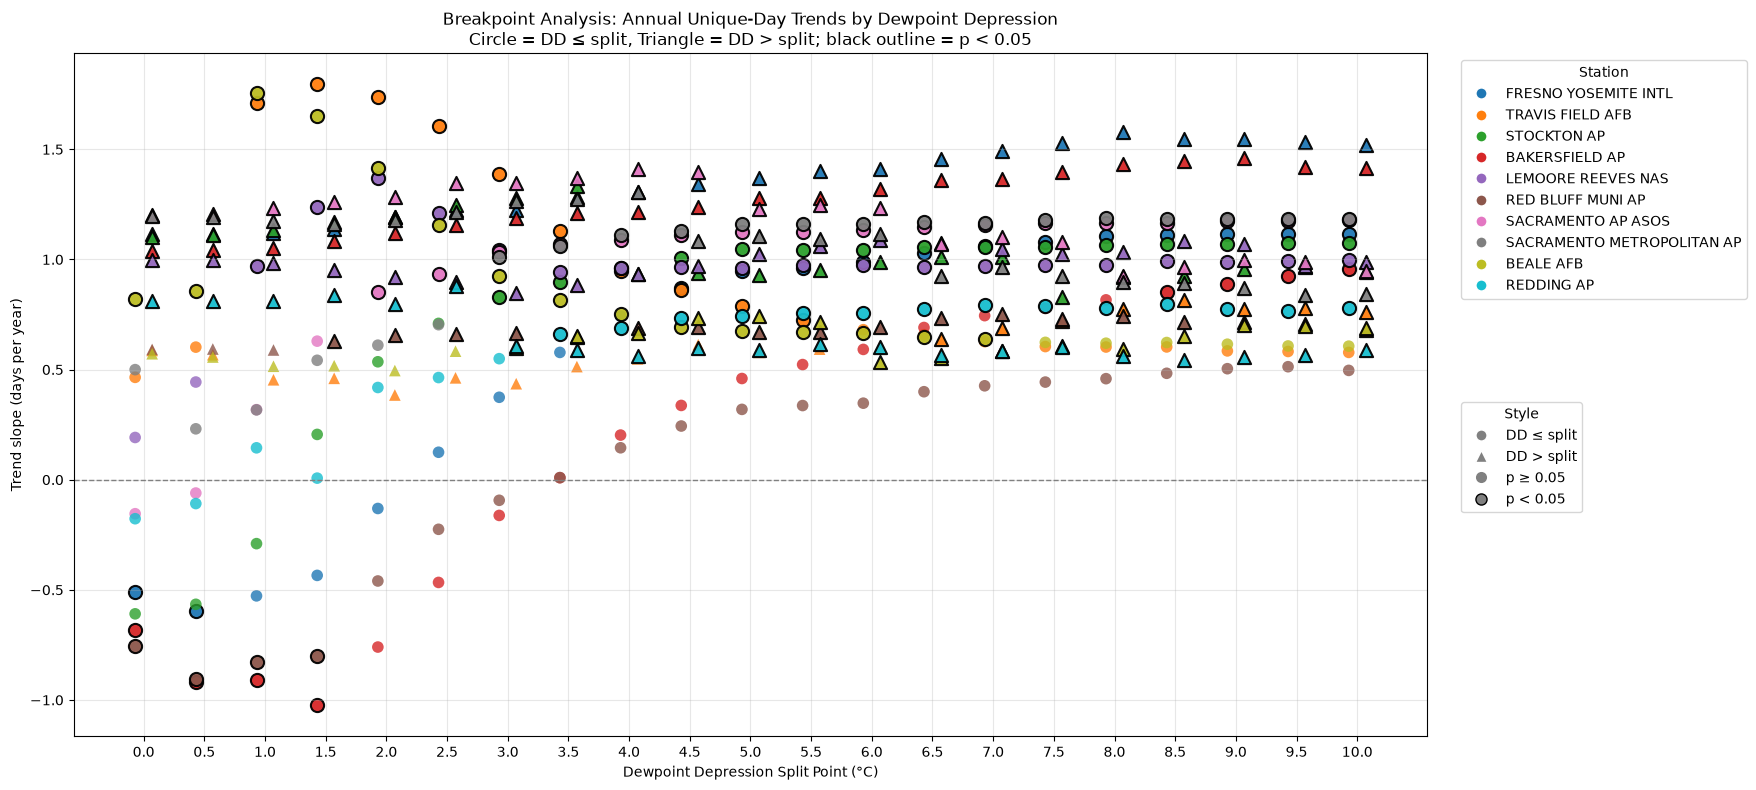

,split,side,STATION,slope_days_per_year,p_value,significant
3,0.0,<=,BAKERSFIELD AP,-0.681586,0.001164,True
5,0.0,<=,RED BLUFF MUNI AP,-0.755584,0.010129,True
0,0.0,<=,FRESNO YOSEMITE INTL,-0.510337,0.024677,True
8,0.0,<=,BEALE AFB,0.820108,0.042127,True
2,0.0,<=,STOCKTON AP,-0.608919,0.068401,False
...,...,...,...,...,...,...
417,10.0,>,SACRAMENTO METROPOLITAN AP,0.842194,0.001796,True
411,10.0,>,TRAVIS FIELD AFB,0.763051,0.002377,True
418,10.0,>,BEALE AFB,0.689466,0.002899,True
415,10.0,>,RED BLUFF MUNI AP,0.677911,0.011270,True


In [33]:
# Breakpoint analysis using unique measured days per year.
# For each dewpoint-depression split point, calculate trends for:
# DD <= split and DD > split, since 1980.

dd_splitpoints = np.arange(0, 10.5, 0.5)
breakpoint_day_records = []

for split in dd_splitpoints:
    df_le = CV_rows_selected[
        CV_rows_selected["HourlyDewpointDepression"] <= split
    ]
    df_gt = CV_rows_selected[
        CV_rows_selected["HourlyDewpointDepression"] > split
    ]

    for side_label, df_side in [("<=", df_le), (">", df_gt)]:
        daily = (
            df_side[df_side["year"] >= 1980]
            [["STATION", "year", "month", "day"]]
            .drop_duplicates()
        )

        yearly_days = (
            daily.groupby(["STATION", "year"])
            .size()
            .reset_index(name="days")
        )

        for station in station_names:
            station_data = (
                yearly_days[yearly_days["STATION"] == station]
                .sort_values("year")
            )

            if len(station_data) < 3:
                continue

            x = station_data["year"].to_numpy()
            y = station_data["days"].to_numpy()

            slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

            breakpoint_day_records.append({
                "split": split,
                "side": side_label,
                "STATION": station,
                "slope_days_per_year": slope,
                "p_value": p_value,
                "significant": bool(np.isfinite(p_value) and p_value < 0.05),
            })

breakpoint_days_df = pd.DataFrame(breakpoint_day_records)

# Plot
fig, ax = plt.subplots(figsize=(16, 8))

station_colors = dict(
    zip(station_names, plt.cm.tab10(np.linspace(0, 1, len(station_names))))
)

side_offset = {"<=": -0.07, ">": 0.07}

for station in station_names:
    station_data = breakpoint_days_df[
        breakpoint_days_df["STATION"] == station
    ]

    for side in ["<=", ">"]:
        side_data = station_data[station_data["side"] == side]

        if side_data.empty:
            continue

        marker = "o" if side == "<=" else "^"
        x_values = side_data["split"].to_numpy() + side_offset[side]

        nonsignificant = side_data[~side_data["significant"]]
        significant = side_data[side_data["significant"]]

        ax.scatter(
            nonsignificant["split"].to_numpy() + side_offset[side],
            nonsignificant["slope_days_per_year"],
            s=70,
            color=station_colors[station],
            alpha=0.8,
            edgecolors="none",
            marker=marker,
        )

        ax.scatter(
            significant["split"].to_numpy() + side_offset[side],
            significant["slope_days_per_year"],
            s=90,
            color=station_colors[station],
            alpha=0.95,
            edgecolors="black",
            linewidths=1.5,
            marker=marker,
        )

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xticks(dd_splitpoints)
ax.set_xlabel("Dewpoint Depression Split Point (°C)")
ax.set_ylabel("Trend slope (days per year)")
ax.set_title(
    "Breakpoint Analysis: Annual Unique-Day Trends by Dewpoint Depression\n"
    "Circle = DD ≤ split, Triangle = DD > split; black outline = p < 0.05"
)
ax.grid(True, alpha=0.3)

station_handles = [
    plt.Line2D(
        [0], [0],
        marker="o",
        color="w",
        label=station,
        markerfacecolor=station_colors[station],
        markersize=8,
    )
    for station in station_names
]

legend1 = ax.legend(
    handles=station_handles,
    title="Station",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
)
ax.add_artist(legend1)

style_handles = [
    plt.Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="DD ≤ split",
        markerfacecolor="gray",
        markersize=8,
    ),
    plt.Line2D(
        [0], [0],
        marker="^",
        color="w",
        label="DD > split",
        markerfacecolor="gray",
        markersize=8,
    ),
    plt.Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="p ≥ 0.05",
        markerfacecolor="gray",
        markeredgecolor="none",
        markersize=8,
    ),
    plt.Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="p < 0.05",
        markerfacecolor="gray",
        markeredgecolor="black",
        markersize=8,
    ),
]

ax.legend(
    handles=style_handles,
    title="Style",
    loc="upper left",
    bbox_to_anchor=(1.02, 0.5),
)

plt.tight_layout()
plt.show()

display(
    breakpoint_days_df.sort_values(["split", "side", "p_value"])
)